### LSE Business Analytics for Executives

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis of NHS data using Python

This assignment uses real-world data to address a problem faced by the National Health Service (NHS). The analysis utilises Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

#

# Assignment Activity 1

### Plan your approach

## Analysis Plan

### Business Context
The NHS faces a critical decision about capacity expansion vs. optimization.
I will analyze appointment data to answer:
1. Is current capacity adequate?
2. How well are resources being utilized?

### Approach
1. **Data Loading & Cleaning** - Load 3 datasets, check for missing values
2. **Exploratory Analysis** - Count locations, service settings, categories
3. **Temporal Analysis** - Identify trends, seasonal patterns, peak periods
4. **Capacity Assessment** - Analyze waiting times, duration patterns
5. **Utilization Analysis** - Calculate attendance rates, examine modes
6. **Social Media Insights** - Extract trending topics from Twitter
7. **Recommendations** - Synthesize findings into actionable advice

### Expected Deliverables
- Comprehensive visualizations
- Statistical insights on capacity and utilization
- Evidence-based recommendations

#

# Assignment Activity 2

### Prepare your workstation

## Import of libraries, NHS files ad, ar and nc, and NHS names file

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')


# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)


# Import the files to DataFrames using aliases ad, ar and nc.
# These will have regional names added and renamed ad, ar and nc.
ad = pd.read_csv('actual_duration.csv')
ar = pd.read_csv('appointments_regional.csv')
nc = pd.read_excel('national_categories.xlsx')


In [ ]:
 ## I created this file myself to merge with the DataFrames to access names of regions and ICB locations.
nhs_names = pd.read_excel('NHS_names.xlsx')

In [ ]:
nhs_names.head()

,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code
0,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012
1,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012
2,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012
3,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012
4,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012


In [ ]:
nhs_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 4 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_ons_code  137793 non-null  object
 1   sub_icb_location_name      137793 non-null  object
 2   icb_ons_code               137793 non-null  object
 3   region_ons_code            137793 non-null  object
dtypes: object(4)
memory usage: 4.2+ MB


In [ ]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
ad.head()



,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [ ]:
ad_1 = ad.iloc[:3].copy()
print(ad_1)

  sub_icb_location_code sub_icb_location_ons_code  \
0                   00L                 E38000130   
1                   00L                 E38000130   
2                   00L                 E38000130   

                        sub_icb_location_name icb_ons_code region_ons_code  \
0  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
1  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
2  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   

  appointment_date actual_duration  count_of_appointments  
0        01-Dec-21   31-60 Minutes                    364  
1        01-Dec-21   21-30 Minutes                    619  
2        01-Dec-21    6-10 Minutes                   1698  


In [ ]:
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [ ]:
ad.shape

(137793, 8)

In [ ]:
# Determine whether there are missing values.
ad.isnull().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [ ]:
ad.duplicated().sum()

np.int64(0)

In [ ]:
# Determine the metadata of the data set.
metadata = ad.info()
print(metadata)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None


In [ ]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [ ]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [ ]:
# Determine whether there are missing values.
ar.isnull().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [ ]:
# Determine the metadata of the data set.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [ ]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [ ]:
ar.duplicated().sum()

np.int64(21604)

In [ ]:
ar.shape

(596821, 7)

In [ ]:
ar[ar.duplicated()]

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
19292,E54000044,2020-01,Attended,GP,Home Visit,Unknown / Data Quality,1
19308,E54000044,2020-01,Attended,GP,Unknown,Unknown / Data Quality,2
19374,E54000044,2020-01,DNA,GP,Home Visit,8 to 14 Days,1
19417,E54000044,2020-01,DNA,Unknown,Face-to-Face,2 to 7 Days,1
19419,E54000044,2020-01,DNA,Unknown,Face-to-Face,Same Day,6
...,...,...,...,...,...,...,...
596809,E54000050,2022-06,Unknown,Unknown,Telephone,15 to 21 Days,1
596812,E54000050,2022-06,Unknown,Unknown,Telephone,More than 28 Days,1
596814,E54000050,2022-06,Unknown,Unknown,Unknown,1 Day,2
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8


In [ ]:
ar_clean = ar.drop_duplicates()
ar_clean.shape

(575217, 7)

In [ ]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

# View the DataFrame.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [ ]:
# Determine whether there are missing values.
nc.isnull().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [ ]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [ ]:
# Determine the descriptive statistics of the data set.
nc.describe().round(2)

,appointment_date,count_of_appointments
count,817394,817394.00
mean,2022-01-16 00:50:35.860796160,362.18
min,2021-08-01 00:00:00,1.00
25%,2021-10-25 00:00:00,7.00
50%,2022-01-18 00:00:00,25.00
75%,2022-04-07 00:00:00,128.00
max,2022-06-30 00:00:00,16590.00
std,NaN,1084.58


In [ ]:
nc.duplicated().sum()

np.int64(0)

## Explore the data set

**Question 1:** How many locations are there in the data set?

**Answer 1:** NHS England is divided into 7 regions, 42 ICBs (Integrated Care Boards) and 106 sub-ICG locations.

In [ ]:
# Determine the number of locations.
ad['sub_icb_location_name'].nunique()


# Also check ICBs and regions
print(f"Unique ICBs: {ad['icb_ons_code'].nunique():,}")
print(f"Unique Sub-ICBs: {ad['sub_icb_location_ons_code'].nunique():,}")
print(f"Unique Regions: {ad['region_ons_code'].nunique():,}")

Unique ICBs: 42
Unique Sub-ICBs: 106
Unique Regions: 7


**Question 2:** What are the five locations with the highest number of appointments?



In [ ]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from nc.
# This code also renames the columns and returns the top five records.


# Calculate and print the sum of appointments in nc.
total_nc = nc['count_of_appointments'].sum()
print( "Total Appointment in nc :" , total_nc)



# Determine the top five locations based on record count.
nc.Top_5 = nc.groupby('sub_icb_location_name')['count_of_appointments'].sum().sort_values(ascending=False).head(5) .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in nc'})


# Add '% of Total' column and view the top 5 in a table.
nc.Top_5['% of Total'] = nc.Top_5['Total Appointments in nc']/total_nc * 100
nc.Top_5.round(1)





Total Appointment in nc : 296046770


,Sub ICB Location,Total Appointments in nc,% of Total
0,NHS North West London ICB - W2U3Z,12142390,4.1
1,NHS North East London ICB - A3A8R,9588891,3.2
2,NHS Kent and Medway ICB - 91Q,9286167,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102,2.8
4,NHS South East London ICB - 72Q,7850170,2.7


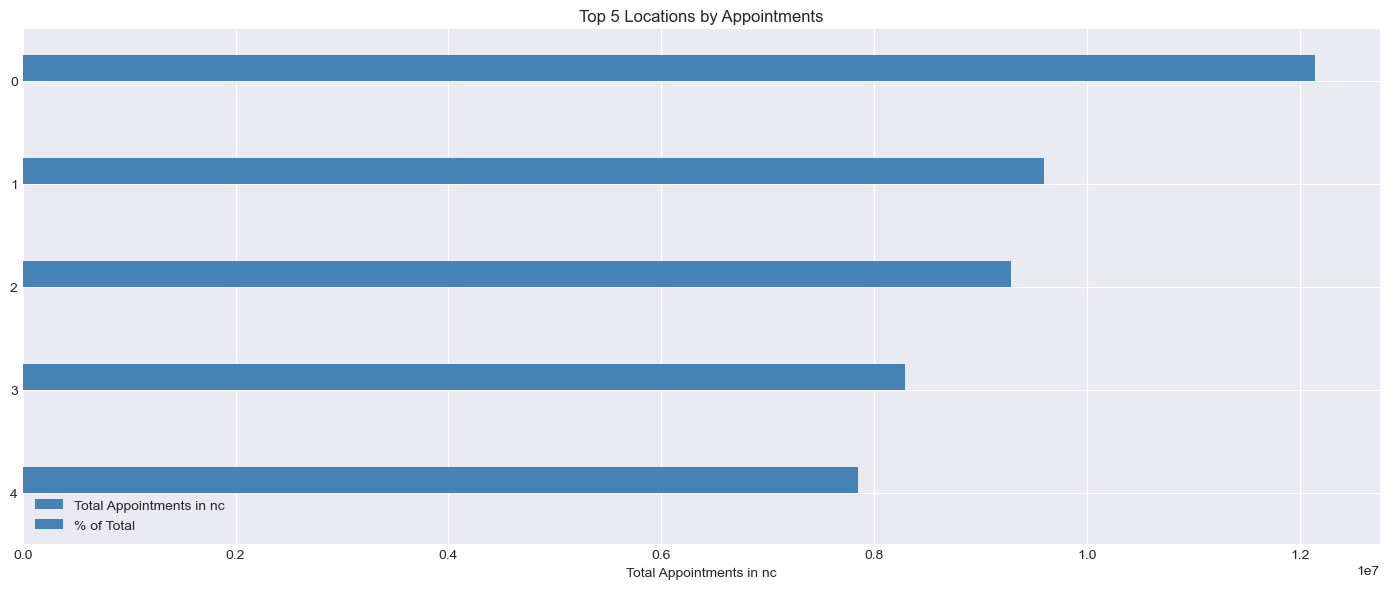

In [ ]:
# Visualize Top  five locations with the highest number of appointments
nc.Top_5.plot (kind='barh', color='steelblue')
plt.xlabel('Total Appointments in nc')
plt.title('Top 5 Locations by Appointments')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from ad.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all 106 sub ICB locations.

ad_top_5 = ad.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in ad'})

total_ad = ad['count_of_appointments'].sum()
print("Total appointments in ad:",total_ad)

ad_top_5['% of Total'] = ad_top_5['Total Appointments in ad']/total_ad * 100
ad_top_5.round(1)

Total appointments in ad: 167980692


,Sub ICB Location,Total Appointments in ad,% of Total
0,NHS North West London ICB - W2U3Z,6976986,4.2
1,NHS North East London ICB - A3A8R,5341883,3.2
2,NHS Kent and Medway ICB - 91Q,5209641,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,4712737,2.8
4,NHS South East London ICB - 72Q,4360079,2.6


In [ ]:
nhs_names_unique = nhs_names[['icb_ons_code',
                             'sub_icb_location_name',
                             'sub_icb_location_ons_code']].drop_duplicates(subset='icb_ons_code')

In [ ]:
nhs_names_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 0 to 135029
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   icb_ons_code               42 non-null     object
 1   sub_icb_location_name      42 non-null     object
 2   sub_icb_location_ons_code  42 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [ ]:
ar_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575217 entries, 0 to 596819
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       575217 non-null  object
 1   appointment_month                  575217 non-null  object
 2   appointment_status                 575217 non-null  object
 3   hcp_type                           575217 non-null  object
 4   appointment_mode                   575217 non-null  object
 5   time_between_book_and_appointment  575217 non-null  object
 6   count_of_appointments              575217 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 35.1+ MB


In [ ]:
# Merge ad with nhs_names to add columns for icb_name and region_name.
ar_1 = pd.merge(ar_clean, 
              nhs_names_unique,\
              how='left', on='icb_ons_code')
ar_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575217 entries, 0 to 575216
Data columns (total 9 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       575217 non-null  object
 1   appointment_month                  575217 non-null  object
 2   appointment_status                 575217 non-null  object
 3   hcp_type                           575217 non-null  object
 4   appointment_mode                   575217 non-null  object
 5   time_between_book_and_appointment  575217 non-null  object
 6   count_of_appointments              575217 non-null  int64 
 7   sub_icb_location_name              575217 non-null  object
 8   sub_icb_location_ons_code          575217 non-null  object
dtypes: int64(1), object(8)
memory usage: 39.5+ MB


In [ ]:
ar_1

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,sub_icb_location_name,sub_icb_location_ons_code
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,NHS Frimley ICB - D4U1Y,E38000252
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,NHS Frimley ICB - D4U1Y,E38000252
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,NHS Frimley ICB - D4U1Y,E38000252
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,NHS Frimley ICB - D4U1Y,E38000252
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,NHS Frimley ICB - D4U1Y,E38000252
...,...,...,...,...,...,...,...,...,...
575212,E54000050,2022-06,Unknown,Unknown,Telephone,Same Day,10,NHS North East and North Cumbria ICB - 00L,E38000130
575213,E54000050,2022-06,Unknown,Unknown,Unknown,15 to 21 Days,13,NHS North East and North Cumbria ICB - 00L,E38000130
575214,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21,NHS North East and North Cumbria ICB - 00L,E38000130
575215,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28,NHS North East and North Cumbria ICB - 00L,E38000130


In [ ]:
# This returns total appointments by ICB location and sorts them in descending order from ar.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all 42 ICB locations.

ar_top_5 = ar_1.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head(5)\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'ICB Name',\
                         'count_of_appointments':'Total Appointments in ar'})

total_ar = ar_1['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

ar_top_5['% of Total'] = ar_top_5['Total Appointments in ar']/total_ar * 100
ar_top_5.round(1)

Total appointments in ar: 742529759


,ICB Name,Total Appointments in ar,% of Total
0,NHS North East and North Cumbria ICB - 00L,43054121,5.8
1,NHS West Yorkshire ICB - 02T,36075020,4.9
2,NHS Greater Manchester ICB - 00T,34003953,4.6
3,NHS Cheshire and Merseyside ICB - 01F,33064205,4.5
4,NHS North West London ICB - W2U3Z,29380767,4.0


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [ ]:
# Determine the number of service settings.
print(nc['service_setting'].value_counts())

nc['service_setting'].nunique()
print(f"Unique service settings: {nc['service_setting'].nunique():,}")

service_setting
General Practice             359274
Primary Care Network         183790
Other                        138789
Extended Access Provision    108122
Unmapped                      27419
Name: count, dtype: int64
Unique service settings: 5


In [ ]:
# This returns total appointments by setting and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all five service settings.

settings = nc.groupby('service_setting')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'service_setting':'Service Setting',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in nc:",total_nc)

settings['% of Total'] = settings['Total Appointments']/total_nc * 100
settings.round(1)

Total appointments in nc: 296046770


,Service Setting,Total Appointments,% of Total
0,General Practice,270811691,91.5
1,Unmapped,11080810,3.7
2,Primary Care Network,6557386,2.2
3,Other,5420076,1.8
4,Extended Access Provision,2176807,0.7


 ### There are 5 service settings; 91.5% of appointments took place in General Practice.

In [ ]:
# Determine the number of context types.
print(nc['context_type'].value_counts())

nc['context_type'].nunique()
print(f"Unique context types: {nc['context_type'].nunique():,}")

context_type
Care Related Encounter    700481
Inconsistent Mapping       89494
Unmapped                   27419
Name: count, dtype: int64
Unique context types: 3


In [ ]:
# This returns total appointments by context type and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all three context types.

context = nc.groupby('context_type')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'context_type':'Context Type',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in nc:",total_nc)

context['% of Total'] = context['Total Appointments']/total_nc * 100
context.round(1)

Total appointments in nc: 296046770


,Context Type,Total Appointments,% of Total
0,Care Related Encounter,257075158,86.8
1,Inconsistent Mapping,27890802,9.4
2,Unmapped,11080810,3.7


### There are three context types; 86.8% of appointments are Care Related Encounters.

In [ ]:
# Determine the number of national categories.
print(nc['national_category'].value_counts())

nc['national_category'].nunique()
print(f"Unique national categories: {nc['national_category'].nunique():,}")

national_category
Inconsistent Mapping                                                   89494
General Consultation Routine                                           89329
General Consultation Acute                                             84874
Planned Clinics                                                        76429
Clinical Triage                                                        74539
Planned Clinical Procedure                                             59631
Structured Medication Review                                           44467
Service provided by organisation external to the practice              43095
Home Visit                                                             41850
Unplanned Clinical Activity                                            40415
Patient contact during Care Home Round                                 28795
Unmapped                                                               27419
Care Home Visit                                           

In [ ]:
# This returns total appointments by national category and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all 18 national categories.

category = nc.groupby('national_category')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'national_category':'National Category',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in nc:",total_nc)

category['% of Total'] = category['Total Appointments']/total_nc * 100
category.round(1)

Total appointments in nc: 296046770


,National Category,Total Appointments,% of Total
0,General Consultation Routine,97271522,32.9
1,General Consultation Acute,53691150,18.1
2,Clinical Triage,41546964,14.0
3,Planned Clinics,28019748,9.5
4,Inconsistent Mapping,27890802,9.4
5,Planned Clinical Procedure,25702694,8.7
6,Unmapped,11080810,3.7
7,Unplanned Clinical Activity,3055794,1.0
8,Home Visit,2144452,0.7
9,Structured Medication Review,1858379,0.6


### There are 18 national categories; general consultations account for the most appointments (routine = 32.9%, acute = 18.1%)

In [ ]:
# Determine the number of appointment statuses.
print(ar['appointment_status'].value_counts())

ar['appointment_status'].nunique()
print(f"Unique appointment status: {ar['appointment_status'].nunique():,}")

appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64
Unique appointment status: 3


In [ ]:
# This returns total appointments by appointment status and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across three appointment statuses.

status = ar_clean.groupby('appointment_status')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'appointment_status':'Appointment Status',\
                         'count_of_appointments':'Total Appointments'})

total_ar = ar_clean['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

status['% of Total'] = status['Total Appointments']/total_ar * 100
status.round(1)

Total appointments in ar: 742529759


,Appointment Status,Total Appointments,% of Total
0,Attended,677646088,91.3
1,Unknown,34050656,4.6
2,DNA,30833015,4.2


### There are three appointment statuses - Attended (91.3% of appointments), Unknonwn (4.6%) and DNA (Did Not Attend - 4.2%)

#

## Further exploration of the data: 
#### How many appointment modes are there?

In [ ]:

# Appointment Mode (efficiency)
# Determine the number of appointment modes.
# This returns total appointments by appointment mode and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total

mode = ar_clean.groupby('appointment_mode')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'appointment_mode':'Appointment Mode',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ar:",total_ar)

mode['% of Total'] = mode['Total Appointments']/total_ar * 100
mode.round(1)

Total appointments in ar: 742529759


,Appointment Mode,Total Appointments,% of Total
0,Face-to-Face,439876928,59.2
1,Telephone,267752505,36.1
2,Unknown,26439308,3.6
3,Home Visit,4848743,0.7
4,Video/Online,3612275,0.5


### There are five appointment modes; most appointments are face-to-face (59.2%) or by telepphone (36.1%)

#### How is time between booking and appointment measured?

In [ ]:

# # Waiting time distribution
# Determine the times between booking and appointment.
# This returns total appointments by time between booking and appointment and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total

wait = ar_clean.groupby('time_between_book_and_appointment')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'time_between_book_and_appointment':'Time between booking and appointment',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ar:",total_ar)

wait['% of Total'] = wait['Total Appointments']/total_ar * 100
wait.round(1)

Total appointments in ar: 742529759


,Time between booking and appointment,Total Appointments,% of Total
0,Same Day,342701908,46.2
1,2 to 7 Days,153749341,20.7
2,8 to 14 Days,86806958,11.7
3,1 Day,67673007,9.1
4,15 to 21 Days,42673981,5.7
5,22 to 28 Days,25503575,3.4
6,More than 28 Days,23024683,3.1
7,Unknown / Data Quality,396306,0.1


 ### Time between booking and appointment is divided into 7 intervals. Most appointments happen on the same day they are booked (46.2%), with a further 20.7% taking place within 2-7 days.

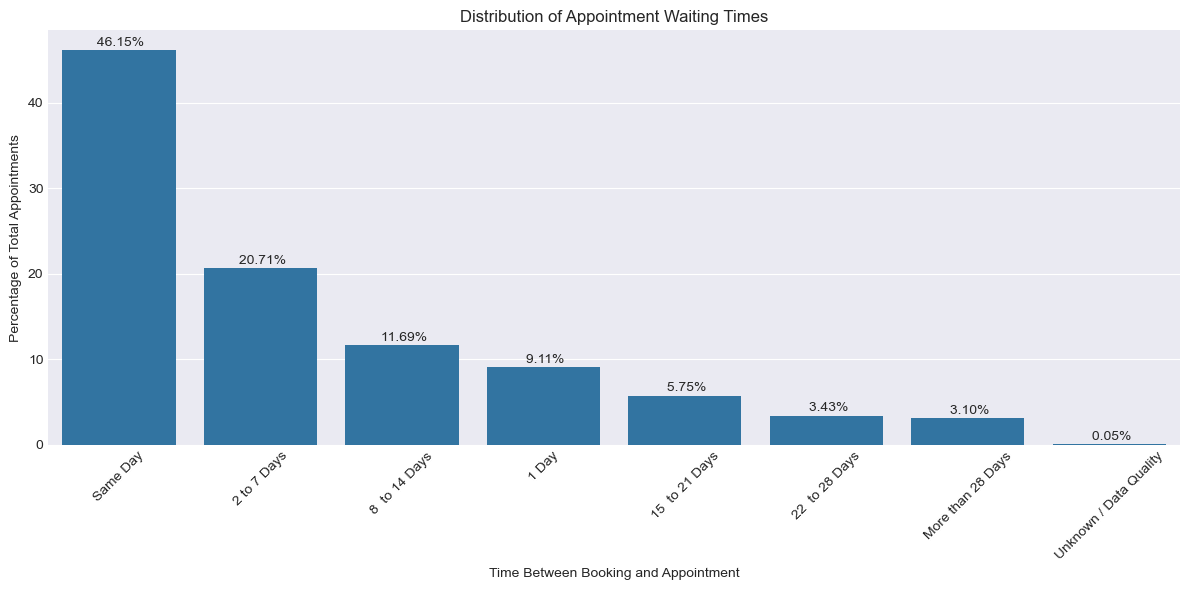

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=wait,
    x='Time between booking and appointment',
    y='% of Total'
)

plt.title('Distribution of Appointment Waiting Times')
plt.xlabel('Time Between Booking and Appointment')
plt.ylabel('Percentage of Total Appointments')

# Add labels
for i, val in enumerate(wait['% of Total']):
    ax.text(i, val + 0.5, f'{val: .2f}%', ha='center')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### How many HCP (healthcare provider) types are there?

In [ ]:
# Determine how many HCP types there are.
# This returns total appointments by HCP type and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total

hcp = ar_clean.groupby('hcp_type')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'hcp_type':'Healthcare Provider',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ar:",total_ar)

hcp['% of Total'] = hcp['Total Appointments']/total_ar * 100
hcp.round(1)

Total appointments in ar: 742529759


,Healthcare Provider,Total Appointments,% of Total
0,GP,379532056,51.1
1,Other Practice staff,339528981,45.7
2,Unknown,23468722,3.2


###  HCPs are split into GPs (51.1% of appointments) and other practice staff (45.7% of appointments)

#### How long do appointments actually last?

In [ ]:
# Determine how long appointments last.
# This returns total appointments by appointment duration and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total

duration = ad.groupby('actual_duration')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'actual_duration':'Actual Duration',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ad:",total_ad)

duration['% of Total'] = duration['Total Appointments']/total_ad * 100
duration.round(1)

Total appointments in ad: 167980692


,Actual Duration,Total Appointments,% of Total
0,Unknown / Data Quality,40284086,24.0
1,6-10 Minutes,33800815,20.1
2,1-5 Minutes,28600865,17.0
3,11-15 Minutes,25160882,15.0
4,16-20 Minutes,16004247,9.5
5,21-30 Minutes,15026365,8.9
6,31-60 Minutes,9103432,5.4


###  24% of appointments are of unknown length; 20% are 6-10 minutes long and 17% are 1-5 minutes long.

# Assignment Activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled?

In [ ]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head()

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

In [ ]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc['appointment_date'].head()

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [ ]:
# Change the date format of ad['appointment_date'].
from sqlalchemy import column


ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# create new column for appointment month
ad['month_year'] = ad['appointment_date'].dt.to_period('M')
ad['Month']= ad['appointment_date'].dt.month

#create new column for appointment year
ad['year'] = ad['appointment_date'].dt.year


ad.head()


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,month_year,Month,year
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,2021-12,12,2021
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,2021-12,12,2021
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,2021-12,12,2021
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,2021-12,12,2021
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,2021-12,12,2021


In [ ]:
# Change the date format of ar['appointment_month'].
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# View the DataFrame.
ar.dtypes

icb_ons_code                                 object
appointment_month                    datetime64[ns]
appointment_status                           object
hcp_type                                     object
appointment_mode                             object
time_between_book_and_appointment            object
count_of_appointments                         int64
dtype: object

In [ ]:
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'])
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month        datetime64[ns]
dtype: object

In [ ]:
# Determine the minimum and maximum dates in the ad, nc and ar DataFrame.
# Use appropriate docstrings.
# Determine the date range of appointments.
print("Actual Duration:")
print(f"  Start: {ad['appointment_date'].min()}")
print(f"  End: {ad['appointment_date'].max()}")
duration_days_ad = (ad['appointment_date'].max() - ad['appointment_date'].min()).days 
print(f"  Duration: {(ad['appointment_date'].max() - ad['appointment_date'].min()).days} days")
duration_months_ad = duration_days_ad / 30
print(f"Duration: {duration_months_ad: .1f} months")



print("\nNational Categories:")
print(f"  Start: {nc['appointment_date'].min()}")
print(f"  End: {nc['appointment_date'].max()}")
duration_days_nc = (nc['appointment_date'].max() - nc['appointment_date'].min()).days 
print(f" Duration: {(nc['appointment_date'].max() - nc['appointment_date'].min()).days} days")
duration_months_nc = duration_days_nc / 30
print(f"Duration: {duration_months_nc: .1f} months")

print("\nRegional Appointments:")
print(f"  Start: {ar['appointment_month'].min()}")
print(f"  End: {ar['appointment_month'].max()}")
duration_days_ar = (ar['appointment_month'].max() - ar['appointment_month'].min()).days
print(f" Duration: {(ar['appointment_month'].max() - ar['appointment_month'].min()).days} days")
duration_months_ar = duration_days_ar / 30
print(f"Duration: {duration_months_ar: .1f} months")



Actual Duration:
  Start: 2021-12-01 00:00:00
  End: 2022-06-30 00:00:00
  Duration: 211 days
Duration:  7.0 months

National Categories:
  Start: 2021-08-01 00:00:00
  End: 2022-06-30 00:00:00
 Duration: 333 days
Duration:  11.1 months

Regional Appointments:
  Start: 2020-01-01 00:00:00
  End: 2022-06-01 00:00:00
 Duration: 882 days
Duration:  29.4 months


### -In ad, appointments run from 1st December 2021 - 30th June 2022 (7 months)
### -In ar, appointments run from January 2020 - June 2022 (30 months)
### -In nc, appointments run from 1st August 2021 - 30th June 2022 (11 months)

**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [ ]:
nc['sub_icb_location_name'].unique()

array(['NHS North East and North Cumbria ICB - 00L',
       'NHS North East and North Cumbria ICB - 00N',
       'NHS North East and North Cumbria ICB - 00P',
       'NHS Lancashire and South Cumbria ICB - 00Q',
       'NHS Lancashire and South Cumbria ICB - 00R',
       'NHS Greater Manchester ICB - 00T',
       'NHS Greater Manchester ICB - 00V',
       'NHS Lancashire and South Cumbria ICB - 00X',
       'NHS Greater Manchester ICB - 00Y',
       'NHS Lancashire and South Cumbria ICB - 01A',
       'NHS Greater Manchester ICB - 01D',
       'NHS Lancashire and South Cumbria ICB - 01E',
       'NHS Cheshire and Merseyside ICB - 01F',
       'NHS Greater Manchester ICB - 01G',
       'NHS North East and North Cumbria ICB - 01H',
       'NHS Cheshire and Merseyside ICB - 01J',
       'NHS Lancashire and South Cumbria ICB - 01K',
       'NHS Cheshire and Merseyside ICB - 01T',
       'NHS Cheshire and Merseyside ICB - 01V',
       'NHS Greater Manchester ICB - 01W',
       'NHS Cheshire

In [ ]:
print((nc['sub_icb_location_name']== 'NHS North West London ICB - W2U3Z').sum())


13007


In [ ]:
# For each of these service settings, determine the number of records available for the period and the location. 
# This will use nc as it contains service setting information.

nw_london = nc[nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z']
print("Total number of appointments in NW London:", nw_london['count_of_appointments'].sum())

Total number of appointments in NW London: 12142390


In [ ]:
# For each of these service settings, determine the number of records available for the period and the location.
# Filter date range
nw_london_filtered = nc[
    (nc['appointment_date'].between('2022-01-01','2022-06-01')) &
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z')
]
nw_london_total = nw_london_filtered['count_of_appointments'].sum()


# Group by service setting
result = (
    nw_london_filtered
    .groupby('service_setting')['count_of_appointments']
    .sum().sort_values( ascending=False).reset_index()\
        .rename(columns={'service_setting':'Service Setting',\
                         'count_of_appointments':'Total Appointments'})
)

# Most popular
print("Total number of appointments in NW London between 1st Jan 2022 - 1st June 2022:"\
      , nw_london_total)
result['% of Total'] = result['Total Appointments']/nw_london_total * 100
result.round(1)


Total number of appointments in NW London between 1st Jan 2022 - 1st June 2022: 5556241


,Service Setting,Total Appointments,% of Total
0,General Practice,4804239,86.5
1,Unmapped,391106,7.0
2,Other,152897,2.8
3,Primary Care Network,109840,2.0
4,Extended Access Provision,98159,1.8


**Question 3:** Which month had the highest number of appointments?

In [ ]:
monthly_appointments = ad.groupby('Month')['count_of_appointments'].sum().sort_values(ascending=False)
print(monthly_appointments)

Month
3     27170002
5     25343941
6     23715317
1     23597196
2     23351939
12    22853483
4     21948814
Name: count_of_appointments, dtype: int64


In [ ]:
months = ar_clean.groupby('appointment_month')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'appointment_month':'Appointment Month',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ar (with duplicates removed):",total_ar)

months['% of Total'] = months['Total Appointments']/total_ar * 100
months.round(1)

Total appointments in ar (with duplicates removed): 742529759


,Appointment Month,Total Appointments,% of Total
0,2021-11,30395923,4.1
1,2021-10,30296850,4.1
2,2022-03,29586020,4.0
3,2021-09,28514685,3.8
4,2020-10,28296051,3.8
5,2022-05,27478652,3.7
6,2021-03,27216974,3.7
7,2020-01,27191758,3.7
8,2021-06,26775653,3.6
9,2020-09,26706462,3.6


In [ ]:
# Total appointments by month can also be viewed as a time series. 
# This shows a dip in appointments in spring 2020.
month_series = ar_clean.groupby('appointment_month')[['count_of_appointments']].sum()\
                .reset_index()\
                .rename(columns={'appointment_month':'Appointment Month',\
                         'count_of_appointments':'Total Appointments'})
month_series

,Appointment Month,Total Appointments
0,2020-01,27191758
1,2020-02,24097066
2,2020-03,24039635
3,2020-04,16002488
4,2020-05,16410591
5,2020-06,20678416
6,2020-07,22483207
7,2020-08,20143878
8,2020-09,26706462
9,2020-10,28296051


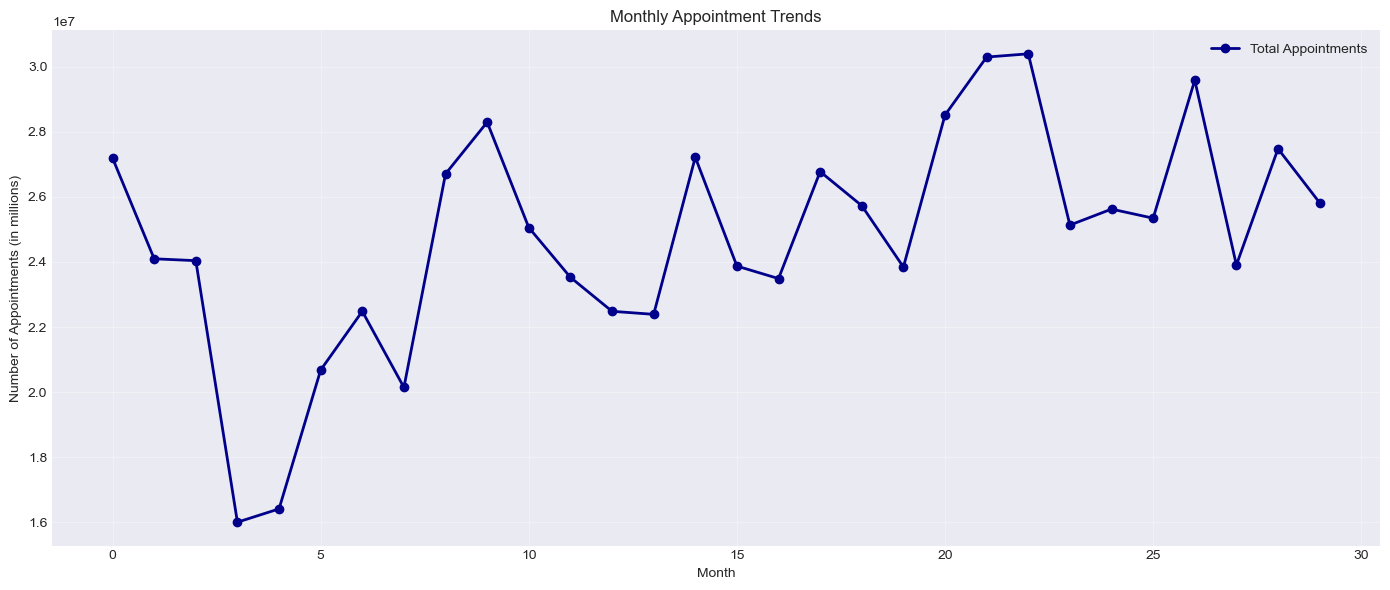

In [ ]:

# Plot trend
month_series.sort_index().plot(kind='line', marker='o', linewidth=2, color='darkblue')
plt.title('Monthly Appointment Trends')
plt.ylabel('Number of Appointments (in millions)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question 4:** What was the total number of records per month?

In [ ]:
# Total number of records per month.
# Count records per month
ad['year_month'] = ad['appointment_date'].dt.to_period('M')

# Convert to "Month Year" format
monthly_records = ad.groupby('month_year').size().sort_index()
monthly_records.index = monthly_records.index.to_timestamp().strftime('%B %Y') # Full month name

print(monthly_records)


month_year
December 2021    19507
January 2022     19643
February 2022    18974
March 2022       21236
April 2022       19078
May 2022         20128
June 2022        19227
dtype: int64


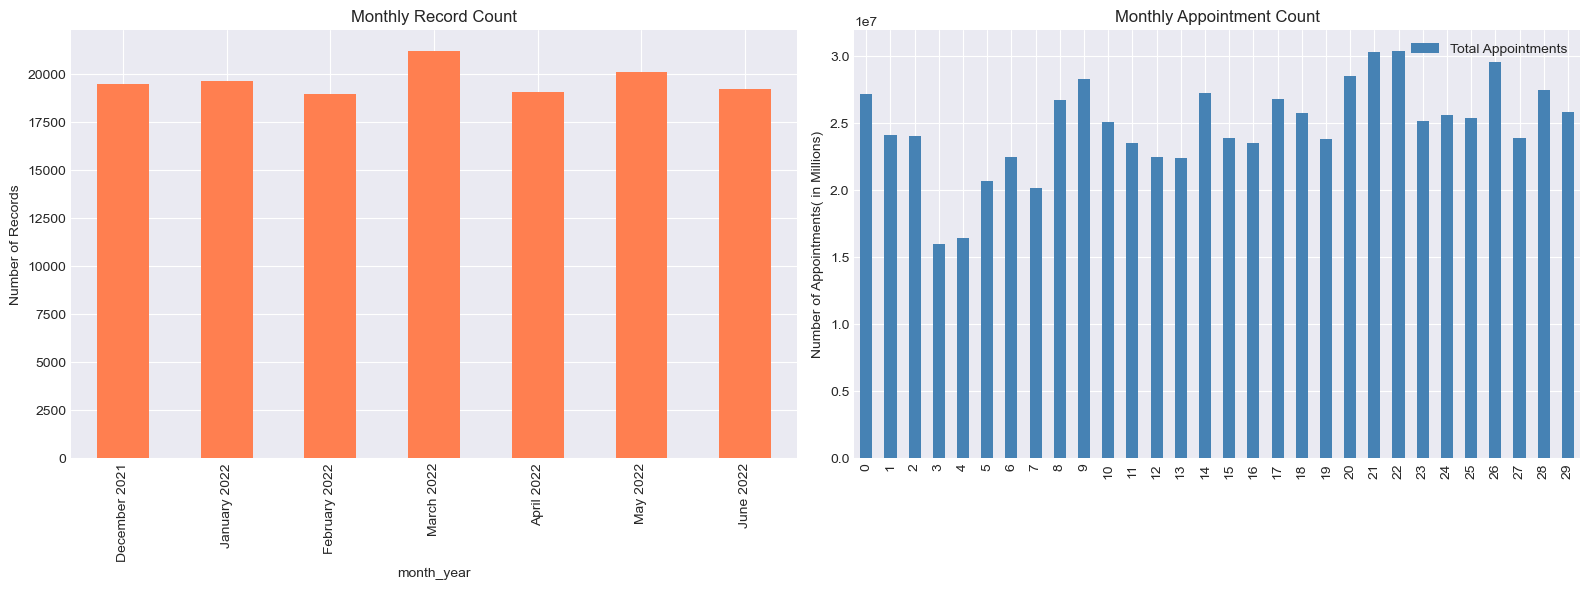

In [ ]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

monthly_records.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Monthly Record Count')
axes[0].set_ylabel('Number of Records')

month_series.sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Appointment Count')
axes[1].set_ylabel('Number of Appointments( in Millions)')

plt.tight_layout()
plt.show()

#

# Assignment Activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [ ]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [ ]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['year_month'] = nc['appointment_date'].dt.to_period('M')
nc['month'] = nc['appointment_month'].dt.month


In [ ]:
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year_month,month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,2021-08,8
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,2021-08,8
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,2021-08,8
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,2021-08,8
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,2021-08,8


In [ ]:
# Aggregate on monthly level and determine the sum of records per month.
Monthly_nc_records = (
    nc.groupby('year_month', as_index=False)['count_of_appointments']
    .sum()
    .sort_values('year_month')
)
      
Monthly_nc_records['month_label'] = Monthly_nc_records['year_month'].dt.strftime('%B %Y') # Full month name
Monthly_nc_records['year_month'] = Monthly_nc_records['year_month'].dt.to_timestamp()

print("Count Of appointments:" , nc['count_of_appointments'].sum())
print(Monthly_nc_records)

Count Of appointments: 296046770
   year_month  count_of_appointments     month_label
0  2021-08-01               23852171     August 2021
1  2021-09-01               28522501  September 2021
2  2021-10-01               30303834    October 2021
3  2021-11-01               30405070   November 2021
4  2021-12-01               25140776   December 2021
5  2022-01-01               25635474    January 2022
6  2022-02-01               25355260   February 2022
7  2022-03-01               29595038      March 2022
8  2022-04-01               23913060      April 2022
9  2022-05-01               27495508        May 2022
10 2022-06-01               25828078       June 2022


In [ ]:
print(type(Monthly_nc_records))
print(Monthly_nc_records.head())
print(Monthly_nc_records.dtypes)

<class 'pandas.core.frame.DataFrame'>
  year_month  count_of_appointments     month_label
0 2021-08-01               23852171     August 2021
1 2021-09-01               28522501  September 2021
2 2021-10-01               30303834    October 2021
3 2021-11-01               30405070   November 2021
4 2021-12-01               25140776   December 2021
year_month               datetime64[ns]
count_of_appointments             int64
month_label                      object
dtype: object


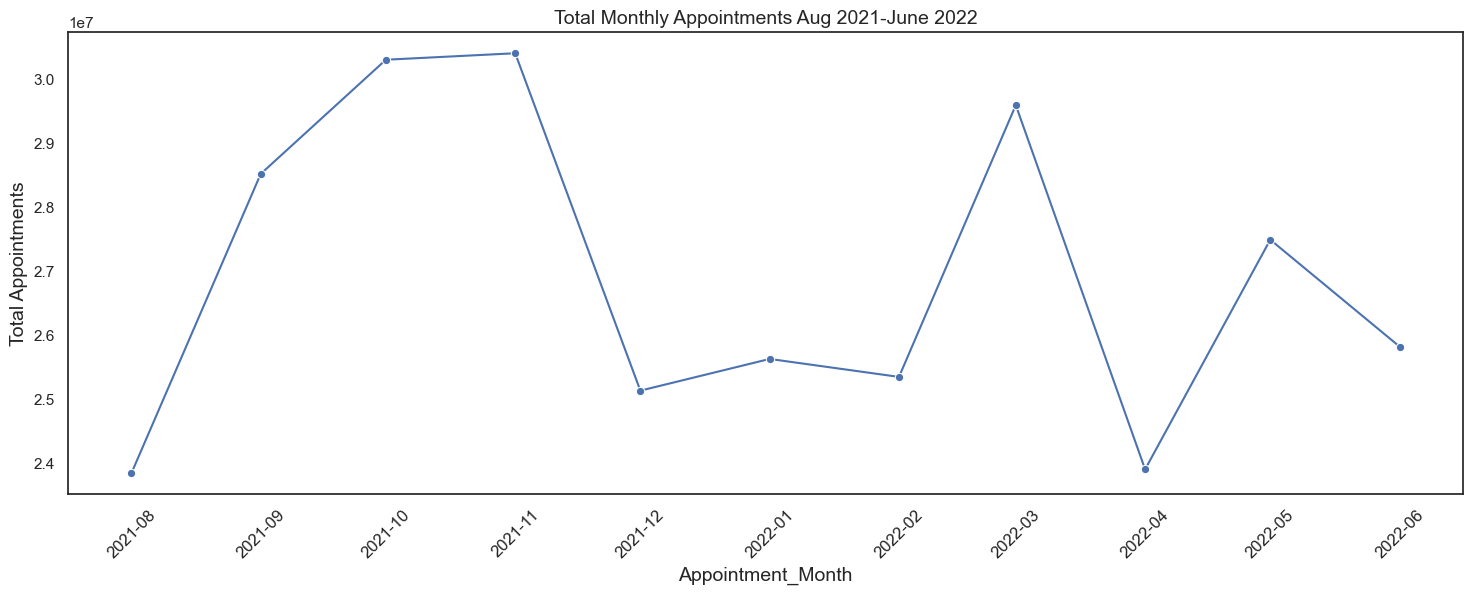

In [ ]:
# Plot a line graph of sum of appointments by month from the nc DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(data=Monthly_nc_records, x='year_month', 
                y='count_of_appointments',
            marker='o')
               
plt.title('Total Monthly Appointments Aug 2021-June 2022', fontsize=14)
plt.xlabel('Appointment_Month', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments', fontsize=14);

**Service settings:**

In [ ]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
service_monthly = nc.groupby(['month', 'service_setting'])['count_of_appointments'].sum().unstack(fill_value=0)
service_monthly

service_setting,Extended Access Provision,General Practice,Other,Primary Care Network,Unmapped
month,,,,,
1,186375,23583053,457440,569044,839562
2,196627,23305934,456153,585300,811246
3,231905,27187368,530677,702176,942912
4,192284,21916791,437402,606270,760313
5,220511,25238620,503327,712280,820770
6,209652,23680374,478813,700599,758640
8,160927,21575852,449101,432448,1233843
9,187906,25940821,527174,530485,1336115
10,209539,27606171,556487,564981,1366656


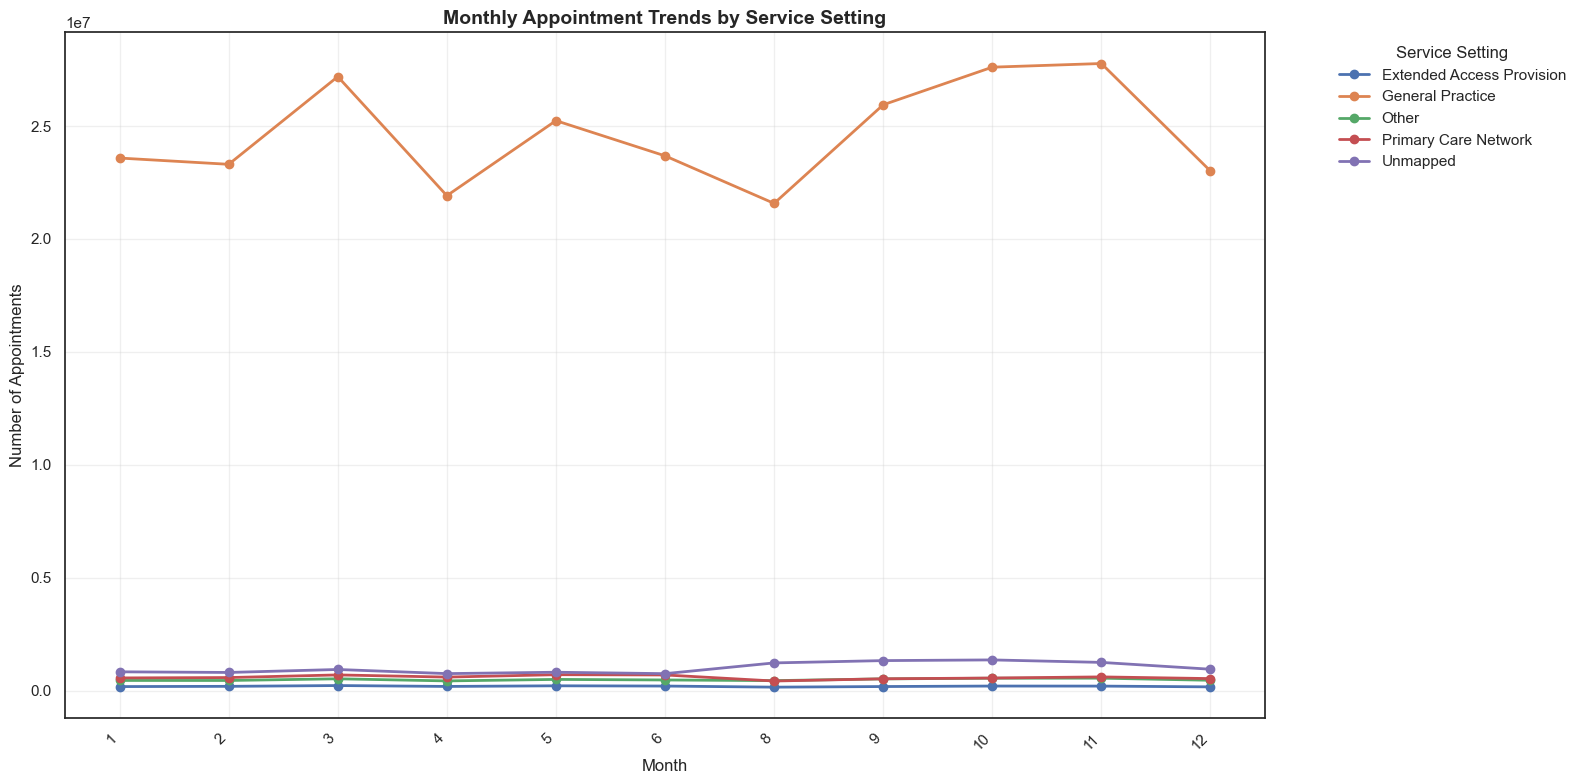

In [ ]:
# Create a lineplot.
# Plot
plt.figure(figsize=(16, 8))
for column in service_monthly.columns:
        plt.plot(service_monthly.index.astype(str), service_monthly[column], 
                marker='o', linewidth=2, label=column)
    
plt.title('Monthly Appointment Trends by Service Setting', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Context types:**

In [ ]:
# Create a separate data set that can be used in future weeks.
context_monthly = nc.groupby(['month', 'context_type'])['count_of_appointments'].sum().unstack(fill_value=0)

# View output.
context_monthly


context_type,Care Related Encounter,Inconsistent Mapping,Unmapped
month,,,
1,22441947,2353965,839562
2,22211021,2332993,811246
3,25928850,2723276,942912
4,20904193,2248554,760313
5,24101243,2573495,820770
6,22621827,2447611,758640
8,20255235,2363093,1233843
9,24404251,2782135,1336115
10,26125201,2811977,1366656


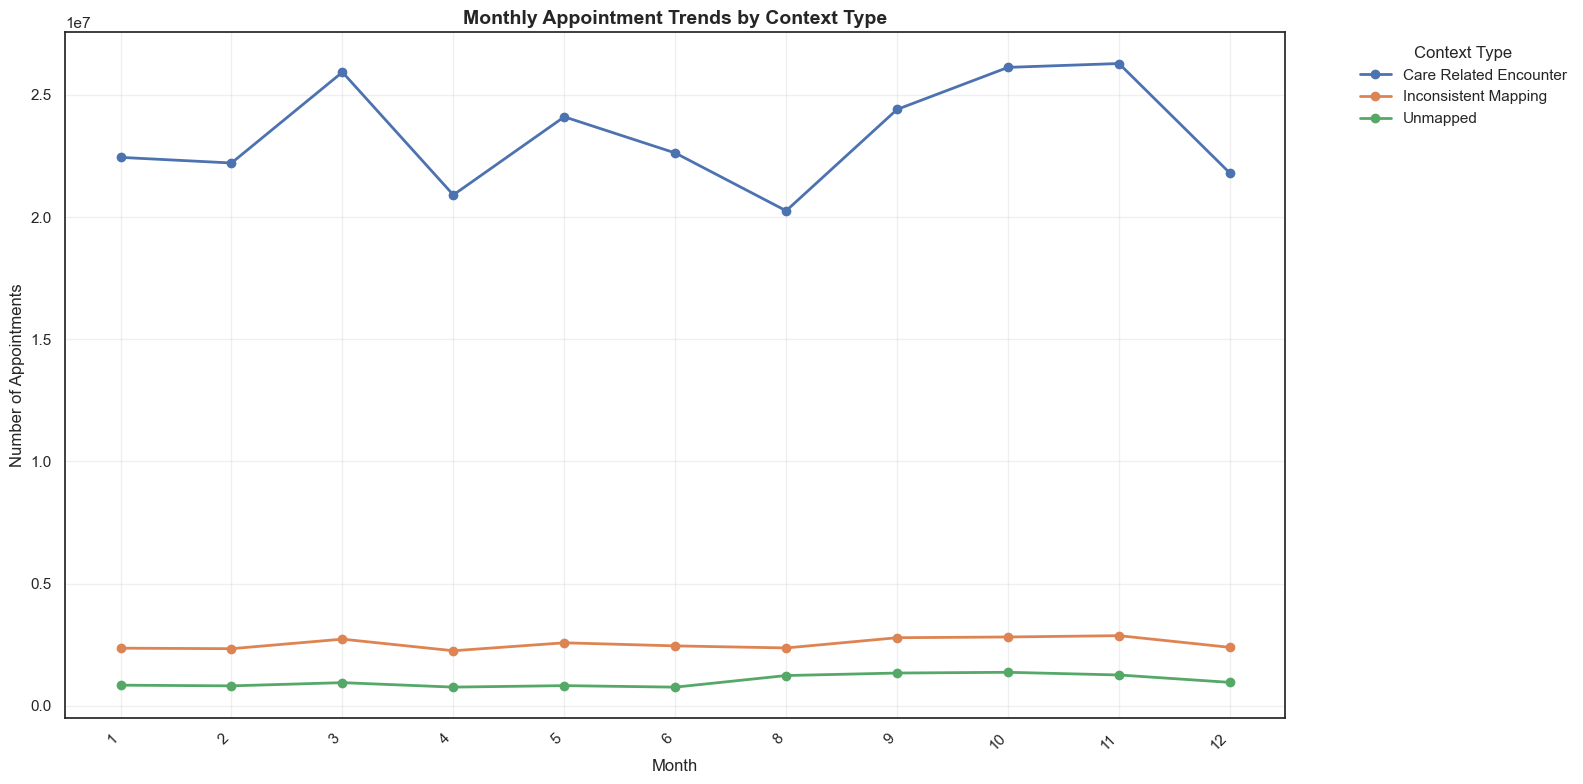

In [ ]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
plt.figure(figsize=(16, 8))
for column in context_monthly.columns:
        plt.plot(context_monthly.index.astype(str), context_monthly[column], 
                marker='o', linewidth=2, label=column)
    
plt.title('Monthly Appointment Trends by Context Type', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.legend(title='Context Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**National categories:**

In [ ]:
# Create a separate data set that can be used in future weeks.
national_category_monthly = nc.groupby(['month', 'national_category'])['count_of_appointments'].sum().unstack(fill_value=0)

# View output.
national_category_monthly

national_category,Care Home Needs Assessment & Personalised Care and Support Planning,Care Home Visit,Clinical Triage,General Consultation Acute,General Consultation Routine,Group Consultation and Group Education,Home Visit,Inconsistent Mapping,Non-contractual chargeable work,Patient contact during Care Home Round,Planned Clinical Procedure,Planned Clinics,Service provided by organisation external to the practice,Social Prescribing Service,Structured Medication Review,Unmapped,Unplanned Clinical Activity,Walk-in
month,,,,,,,,,,,,,,,,,,
1,37988,55860,3777487,4787643,8645563,5108,184279,2353965,12121,74860,1957081,2329241,73134,42533,165890,839562,261010,32149
2,37219,55078,3646672,4767965,8565715,5397,183418,2332993,12650,77638,1956726,2321981,74059,43640,165911,811246,265287,31665
3,43189,65413,4155846,5581504,10074249,6114,214743,2723276,14663,98338,2281907,2708552,87542,52186,195229,942912,311305,38070
4,35282,53715,3301285,4548963,7998377,4921,183950,2248554,11885,87757,1868140,2228734,74919,45690,166146,760313,262083,32346
5,42904,64806,3674229,5208791,9320538,6147,209583,2573495,13623,113703,2141111,2641879,85406,54350,192554,820770,293932,37687
6,40222,61546,3391163,4882755,8691384,5667,193923,2447611,12942,119022,2032073,2556175,81663,55066,187800,758640,274491,35935
8,29676,47583,3704207,4280920,7756045,5161,165061,2363093,10775,31316,1701814,2007880,69206,31486,138570,1233843,241523,34012
9,33503,53519,4118862,4834413,9060243,5892,188756,2782135,13138,34966,2770296,2696591,76461,36077,163167,1336115,275526,42841
10,32441,53713,3966561,4843309,9256788,5528,201362,2811977,12965,40064,3870643,3237242,76947,36642,155493,1366656,288158,47345


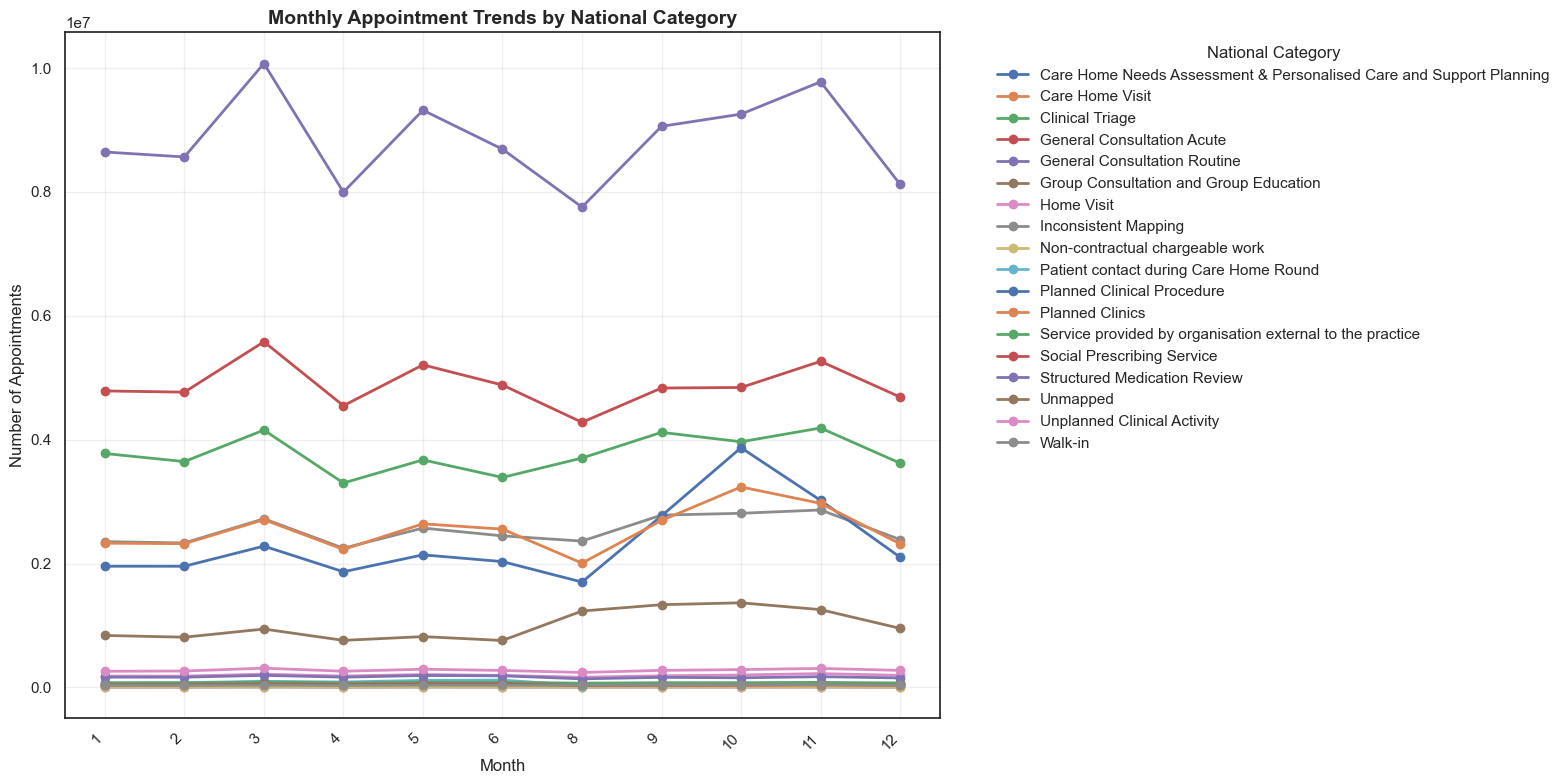

In [ ]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
plt.figure(figsize=(16, 8))
for column in national_category_monthly.columns:
        plt.plot(national_category_monthly.index.astype(str), national_category_monthly[column], 
                marker='o', linewidth=2, label=column)
    
plt.title('Monthly Appointment Trends by National Category', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Monthly trends are examined using ar_clean

### 1. Visualise total appointments by month in ar_clean, across all categories.

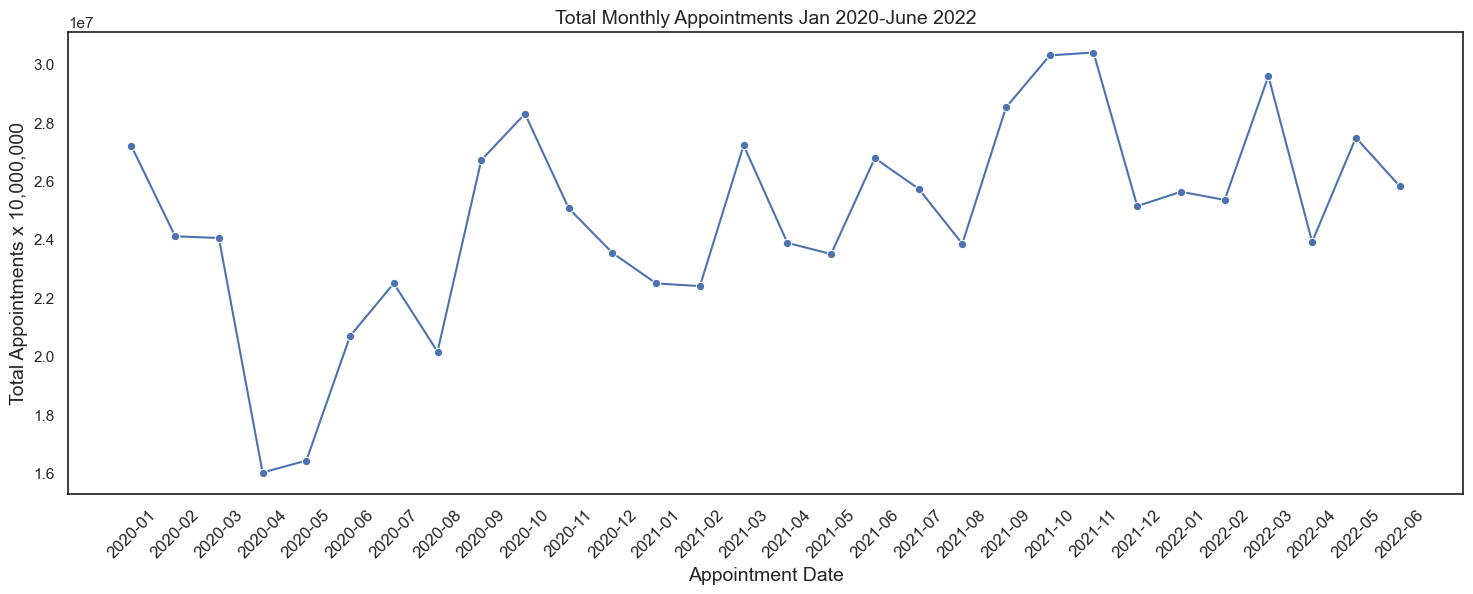

In [ ]:
# Aggregate on monthly level and determine the sum of records per month.
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() to group by month.
ar_month = ar_clean.groupby('appointment_month')[['count_of_appointments']]\
        .sum()\
        .reset_index()\
        .rename(columns={'appointment_month':'Appointment Month',\
                         'count_of_appointments':'Total Appointments'})

# Add a column to show % of total appointments.
ar_month['% of Total'] = ar_month['Total Appointments']/(total_ar) * 100

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(data=ar_month, x='Appointment Month', 
                y='Total Appointments',
            marker='o')
               
plt.title('Total Monthly Appointments Jan 2020-June 2022', fontsize=14)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments x 10,000,000', fontsize=14);

### There is a clear drop in total appointments from the beginning of the first covid lockdown (March 2020). Appointments also fell from Oct 2020 to Feb 2021, when further lockdown measures were in place.This is also the case in Dec 2021 - Feb 2022.

## Changes in appointment mode

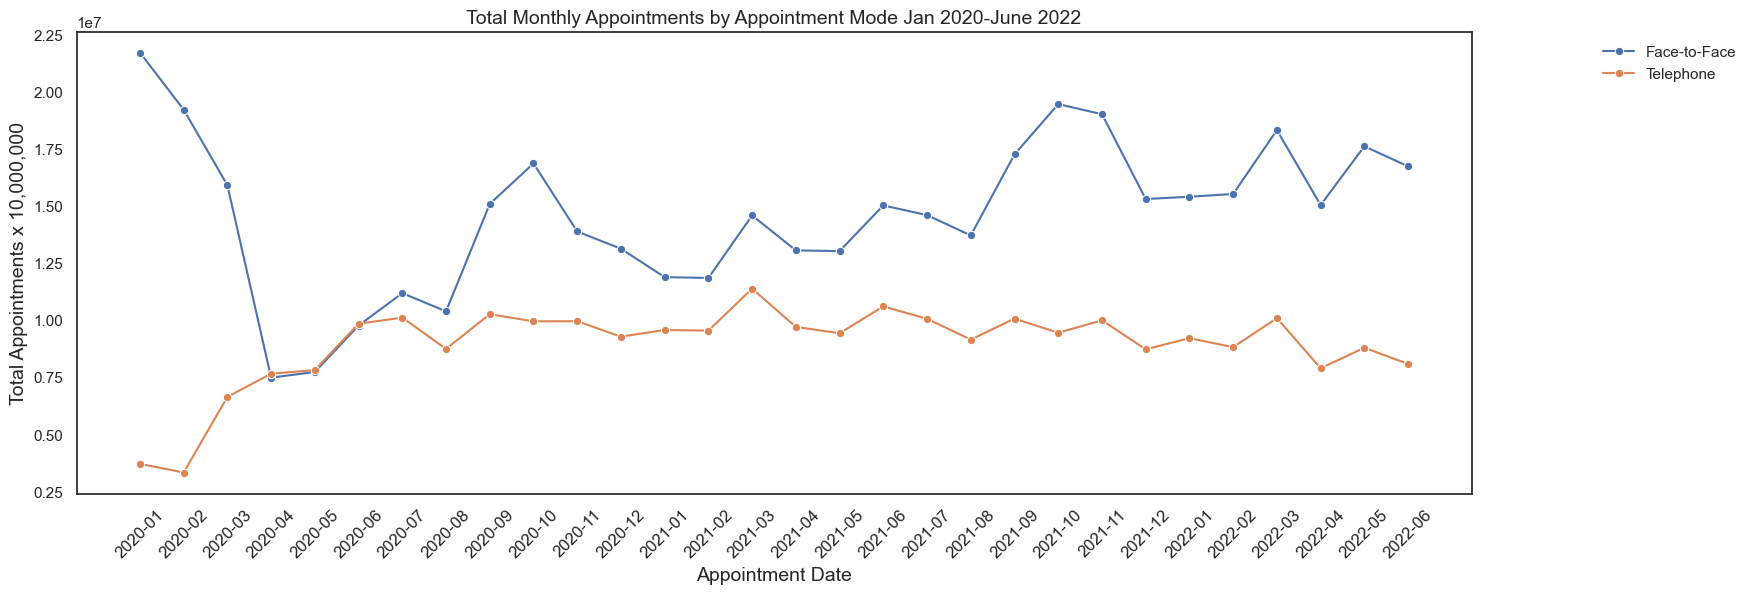

In [ ]:
# Aggregate on monthly level and determine the sum of records per month.
# Number of appointments per month == sum of count_of_appointments by month.

# Create subset DataFrame with 'Telephone' and 'Face to Face' modes only.
ar_two_modes = ar_clean[ar_clean['appointment_mode'].isin(['Face-to-Face','Telephone'])]

# Use the groupby() to group by month and appointment mode.
ar_month_mode = ar_two_modes.groupby(['appointment_month','appointment_mode'])[['count_of_appointments']]\
        .sum()\
        .reset_index()\
        .rename(columns={'appointment_month':'Appointment Month',
                         'appointment_mode':'Appointment Mode',
                         'count_of_appointments':'Total Appointments'})

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(data=ar_month_mode, x='Appointment Month', 
                y='Total Appointments',
             hue='Appointment Mode',
            marker='o')
               
plt.title('Total Monthly Appointments by Appointment Mode Jan 2020-June 2022', fontsize=14)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments x 10,000,000', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1));

### There is a sharp increase in telephone appointments from March 2020 (first covid lockdown), and an even sharper fall in face-to-face appointments from Jan - April 2020

In [ ]:
ar_month_mode.head()

,Appointment Month,Appointment Mode,Total Appointments
0,2020-01,Face-to-Face,21730843
1,2020-01,Telephone,3699600
2,2020-02,Face-to-Face,19228169
3,2020-02,Telephone,3320015
4,2020-03,Face-to-Face,15914207


In [ ]:
# Calculate % of each appointment mode by month for a clearer picture of perferred mode.
ar_month_mode['Monthly %'] = ar_month_mode['Total Appointments']\
                                /ar_month_mode.groupby(['Appointment Month'])\
                                ['Total Appointments'].transform('sum')*100
                                
                             

ar_month_mode.head(10).round(1)

,Appointment Month,Appointment Mode,Total Appointments,Monthly %
0,2020-01,Face-to-Face,21730843,85.5
1,2020-01,Telephone,3699600,14.5
2,2020-02,Face-to-Face,19228169,85.3
3,2020-02,Telephone,3320015,14.7
4,2020-03,Face-to-Face,15914207,70.6
5,2020-03,Telephone,6633965,29.4
6,2020-04,Face-to-Face,7479513,49.4
7,2020-04,Telephone,7650145,50.6
8,2020-05,Face-to-Face,7727487,49.7
9,2020-05,Telephone,7810825,50.3


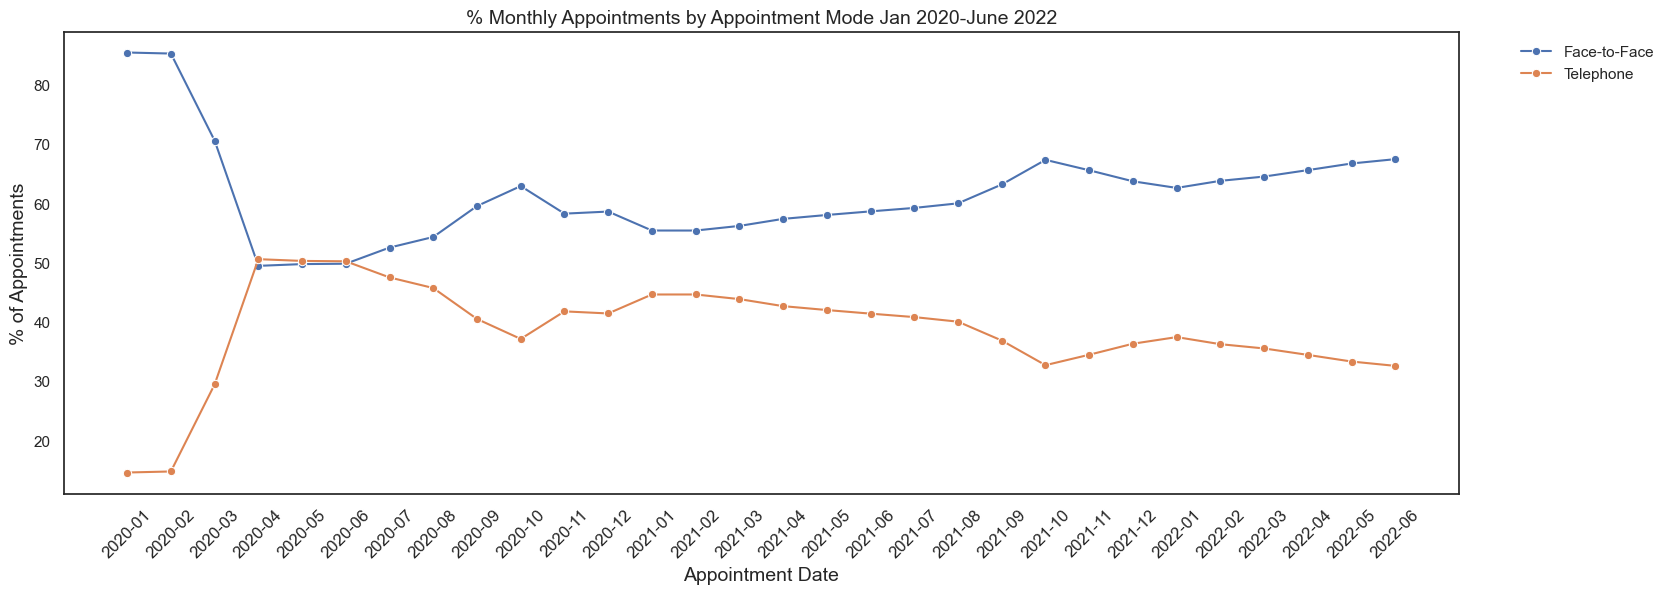

In [ ]:
# Plot a line graph of % of appointments by month and mode from the ar_clean DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(data=ar_month_mode, x='Appointment Month', 
                y='Monthly %',
             hue='Appointment Mode',
            marker='o')
               
plt.title('% Monthly Appointments by Appointment Mode Jan 2020-June 2022', fontsize=14)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('% of Appointments', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1));

In [ ]:
ar_two_modes = ar_clean[ar_clean['appointment_mode'].isin(['Face-to-Face','Telephone'])]

ar_month_mode_pivot = ar_month_mode.pivot_table(index=['Appointment Month'],
                                                       columns='Appointment Mode',
                                                       values='Total Appointments',
                                                       aggfunc=np.sum)

ar_month_mode_pivot


Appointment Mode,Face-to-Face,Telephone
Appointment Month,,
2020-01,21730843,3699600
2020-02,19228169,3320015
2020-03,15914207,6633965
2020-04,7479513,7650145
2020-05,7727487,7810825
2020-06,9760957,9841404
2020-07,11182497,10110231
2020-08,10386960,8738889
2020-09,15090608,10258591


### Viewing the data as a percentage of appointment modes by month highlights the shift more clearly. Telephone consultations, which were relatively uncommon at 14.6% in January 2020, rose sharply and overtook face-to-face appointments by April 2020, reaching 50.6%. Following this peak, there has been a gradual shift back toward face-to-face interactions; however, their share remains lower than pre-2020 levels. Notably, there are visible dips in the proportion of telephone appointments around October 2020 and October 2021.

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [ ]:
# filter the data for the summer months of June, July and August 2021 to review the trends in appointments for these months.
filtered_nc = nc[
    (nc['appointment_month'] >= '2021-06-01') & 
    (nc['appointment_month'] <= '2021-08-31')
]
filtered_nc


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year_month,month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,2021-08,8
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,2021-08,8
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,2021-08,8
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,2021-08,8
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,2021-08,8
...,...,...,...,...,...,...,...,...,...,...
808176,2021-08-31,E54000054,NHS West Yorkshire ICB - X2C4Y,Other,Care Related Encounter,Clinical Triage,20,2021-08-01,2021-08,8
808177,2021-08-31,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Unplanned Clinical Activity,143,2021-08-01,2021-08,8
808178,2021-08-31,E54000054,NHS West Yorkshire ICB - X2C4Y,Primary Care Network,Care Related Encounter,Social Prescribing Service,7,2021-08-01,2021-08,8
808179,2021-08-31,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Home Visit,36,2021-08-01,2021-08,8


In [ ]:
# Create a separate data set that can be used in future weeks.
service_per_season_1 = (
    filtered_nc
    .groupby(['appointment_date', 'service_setting'])['count_of_appointments']
    .sum().reset_index()\
        .rename(columns={'appointment_date':'Appointment Date',\
                         'service_setting':'Service Setting',
                         'count_of_appointments':'Total Appointments'})
   
)
# View output.
service_per_season_1




,Appointment Date,Service Setting,Total Appointments
0,2021-08-01,Extended Access Provision,438
1,2021-08-01,General Practice,3411
2,2021-08-01,Other,401
3,2021-08-01,Primary Care Network,323
4,2021-08-01,Unmapped,1054
...,...,...,...
150,2021-08-31,Extended Access Provision,8281
151,2021-08-31,General Practice,1125584
152,2021-08-31,Other,23181
153,2021-08-31,Primary Care Network,21789


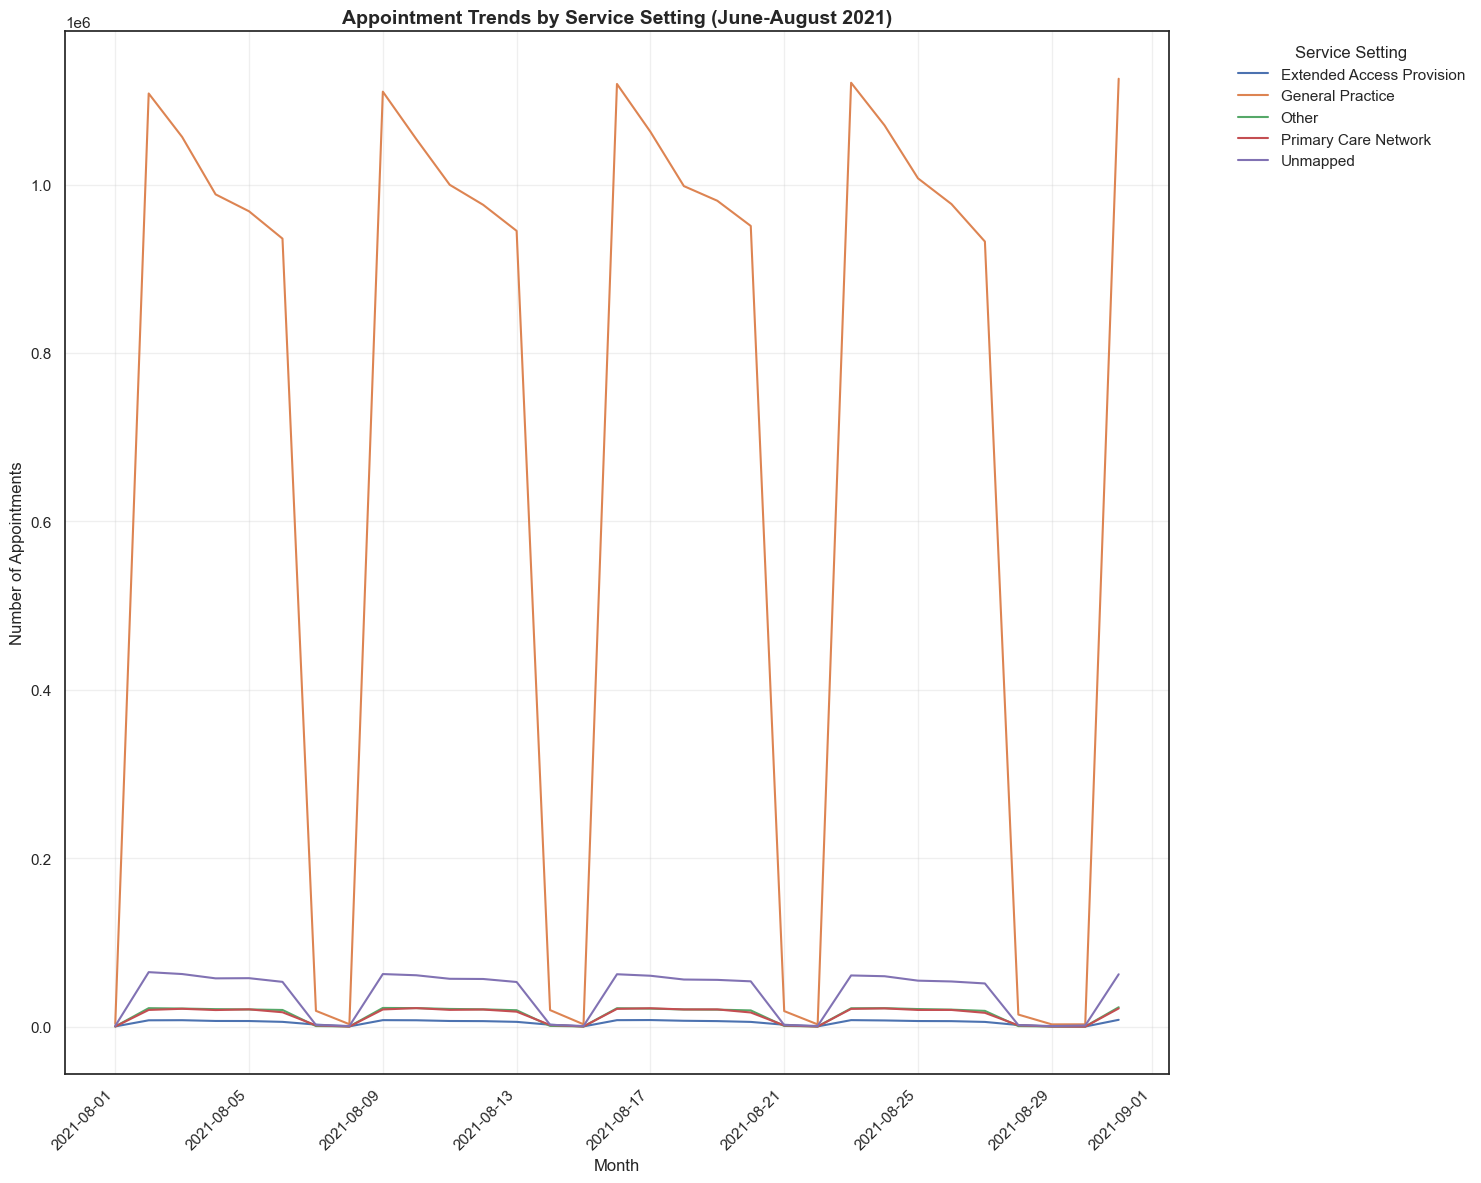

In [ ]:
# Look at June to August 2021 in more detail to allow a closer look.
# Create a barplot.

sns.lineplot(data=service_per_season_1, x='Appointment Date', y='Total Appointments', hue='Service Setting')

plt.title('Appointment Trends by Service Setting (June-August 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Autumn (September to November 2021):**

In [ ]:
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month        datetime64[ns]
year_month                    period[M]
month                             int32
dtype: object

In [ ]:
filtered_nc_1 = nc[
    (nc['appointment_month'] >= '2021-09-01') & 
    (nc['appointment_month'] <= '2021-11-30')
]
filtered_nc_1

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year_month,month
636,2021-09-01,E54000050,NHS North East and North Cumbria ICB - 00L,Unmapped,Unmapped,Unmapped,147,2021-09-01,2021-09,9
637,2021-09-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Structured Medication Review,4,2021-09-01,2021-09,9
638,2021-09-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Planned Clinics,45,2021-09-01,2021-09,9
639,2021-09-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Planned Clinical Procedure,8,2021-09-01,2021-09,9
640,2021-09-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,1,2021-09-01,2021-09,9
...,...,...,...,...,...,...,...,...,...,...
810945,2021-11-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,131,2021-11-01,2021-11,11
810946,2021-11-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Home Visit,1,2021-11-01,2021-11,11
810947,2021-11-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,15,2021-11-01,2021-11,11
810948,2021-11-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Acute,20,2021-11-01,2021-11,11


In [ ]:
# Look at September to November 2021 in more detail to allow a closer look.
service_per_season_2 = (
    filtered_nc_1
    .groupby(['appointment_date', 'service_setting'])['count_of_appointments']
    .sum().reset_index()\
        .rename(columns={'appointment_date':'Appointment Date',\
                         'service_setting':'Service Setting',
                         'count_of_appointments':'Total Appointments'})
   
)
# View output.
service_per_season_2



,Appointment Date,Service Setting,Total Appointments
0,2021-09-01,Extended Access Provision,6916
1,2021-09-01,General Practice,1041879
2,2021-09-01,Other,21796
3,2021-09-01,Primary Care Network,21371
4,2021-09-01,Unmapped,57423
...,...,...,...
450,2021-11-30,Extended Access Provision,9077
451,2021-11-30,General Practice,1254637
452,2021-11-30,Other,24681
453,2021-11-30,Primary Care Network,30215


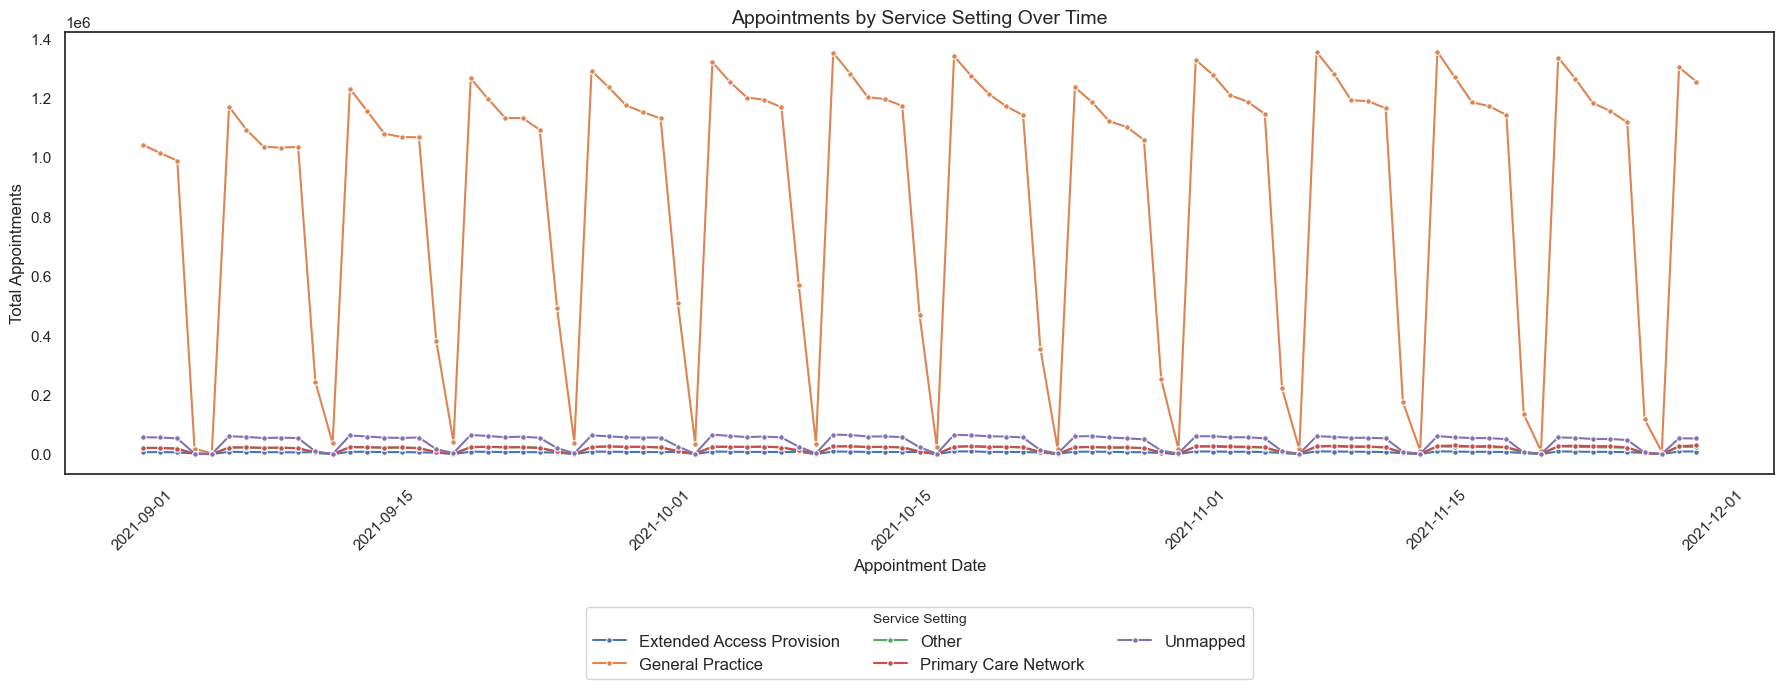

In [ ]:
# Create a lineplot
plt.figure(figsize=(18,6))

ax = sns.lineplot(
    data=service_per_season_2,
    x='Appointment Date',
    y='Total Appointments',
    hue='Service Setting',   # multiple lines
    marker='o',
    markersize=4,
    linewidth=1.5
)

plt.title('Appointments by Service Setting Over Time', fontsize=14)
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Total Appointments', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='Service Setting')
plt.tight_layout()

#Legend below the chart
ax.legend(
    title='Service Setting',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=3,
    fontsize=12,
    title_fontsize=10,
    frameon=True
)

plt.show()

**Winter (December to February 2022):**

In [ ]:
filtered_nc_2 = nc[
    (nc['appointment_month'] >= '2021-12-01') & 
    (nc['appointment_month'] <= '2022-02-28')
]
filtered_nc_2

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year_month,month
2634,2021-12-01,E54000050,NHS North East and North Cumbria ICB - 00L,Unmapped,Unmapped,Unmapped,198,2021-12-01,2021-12,12
2635,2021-12-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Structured Medication Review,5,2021-12-01,2021-12,12
2636,2021-12-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Planned Clinics,52,2021-12-01,2021-12,12
2637,2021-12-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Planned Clinical Procedure,27,2021-12-01,2021-12,12
2638,2021-12-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,30,2021-12-01,2021-12,12
...,...,...,...,...,...,...,...,...,...,...
813632,2022-02-28,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-02-01,2022-02,2
813633,2022-02-28,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,81,2022-02-01,2022-02,2
813634,2022-02-28,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,14,2022-02-01,2022-02,2
813635,2022-02-28,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Acute,28,2022-02-01,2022-02,2


In [ ]:
# Look at December to February 2022 in more detail to allow a closer look.
service_per_season_3 = (
    filtered_nc_2
    .groupby(['appointment_date', 'service_setting'])['count_of_appointments']
    .sum().reset_index()\
        .rename(columns={'appointment_date':'Appointment Date',\
                         'service_setting':'Service Setting',
                         'count_of_appointments':'Total Appointments'})
   
)
# View output.
service_per_season_3




,Appointment Date,Service Setting,Total Appointments
0,2021-12-01,Extended Access Provision,8500
1,2021-12-01,General Practice,1162676
2,2021-12-01,Other,22924
3,2021-12-01,Primary Care Network,26887
4,2021-12-01,Unmapped,49064
...,...,...,...
445,2022-02-28,Extended Access Provision,10538
446,2022-02-28,General Practice,1301433
447,2022-02-28,Other,25280
448,2022-02-28,Primary Care Network,30966


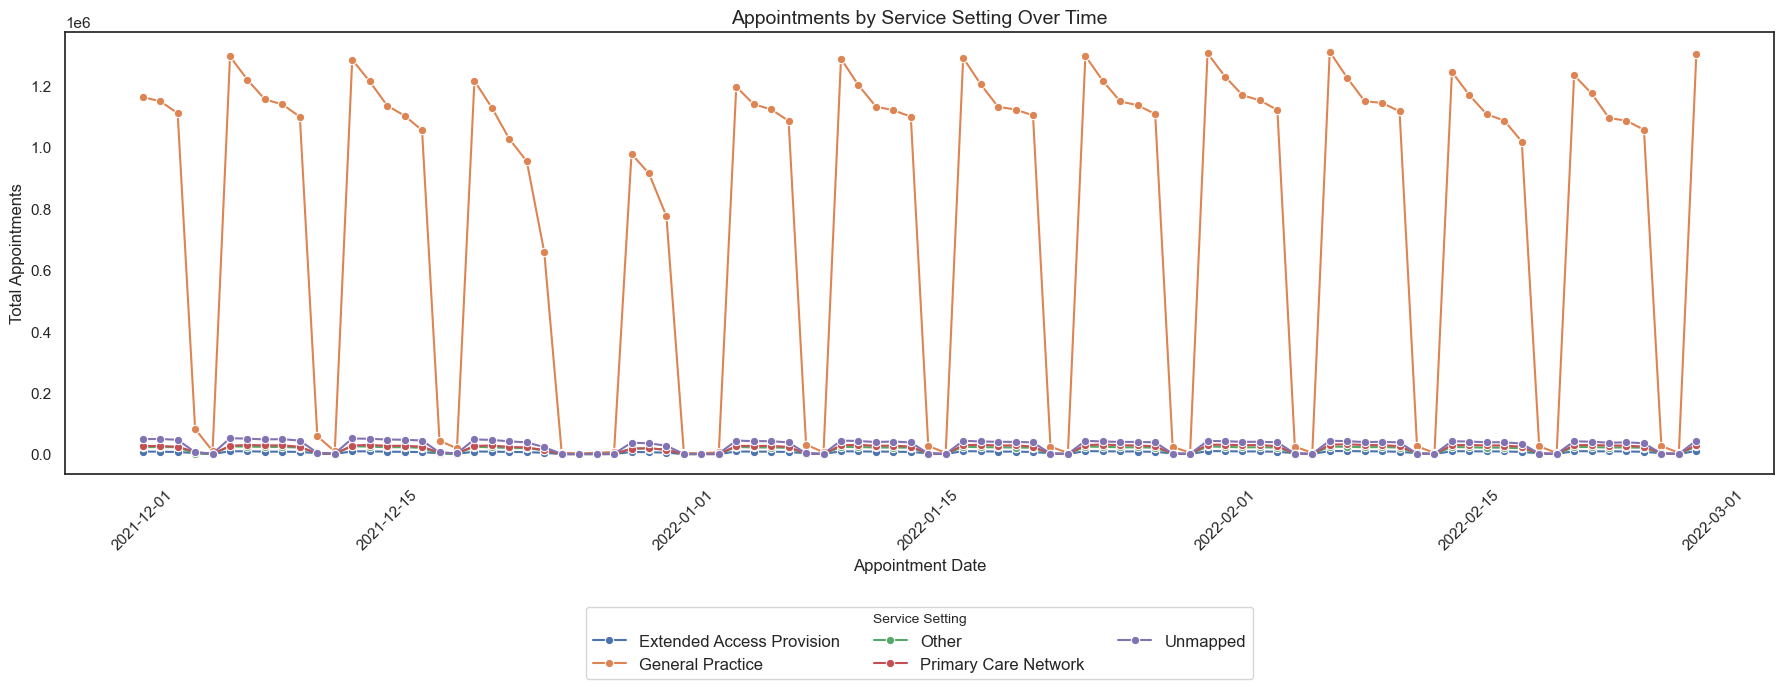

In [ ]:
# Create a lineplot
plt.figure(figsize=(18,6))

bx = sns.lineplot(
    data=service_per_season_3,
    x='Appointment Date',
    y='Total Appointments',
    hue='Service Setting',   # multiple lines
    marker='o'
)

plt.title('Appointments by Service Setting Over Time', fontsize=14)
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Total Appointments', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='Service Setting')
plt.tight_layout()

# legend below the chart
bx.legend(
    title='Service Setting',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=3,
    fontsize=12,
    title_fontsize=10,
    frameon=True)

plt.show()

**Spring (March to May 2022):**

In [ ]:
filtered_nc_3 = nc[
    (nc['appointment_month'] >= '2022-03-01') & 
    (nc['appointment_month'] <= '2022-05-31')
]
filtered_nc_3

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year_month,month
4454,2022-03-01,E54000050,NHS North East and North Cumbria ICB - 00L,Unmapped,Unmapped,Unmapped,156,2022-03-01,2022-03,3
4455,2022-03-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Inconsistent Mapping,Inconsistent Mapping,7,2022-03-01,2022-03,3
4456,2022-03-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Structured Medication Review,19,2022-03-01,2022-03,3
4457,2022-03-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Social Prescribing Service,15,2022-03-01,2022-03,3
4458,2022-03-01,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Planned Clinics,83,2022-03-01,2022-03,3
...,...,...,...,...,...,...,...,...,...,...
816466,2022-05-31,E54000054,NHS West Yorkshire ICB - X2C4Y,Primary Care Network,Care Related Encounter,General Consultation Routine,177,2022-05-01,2022-05,5
816467,2022-05-31,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Planned Clinical Procedure,503,2022-05-01,2022-05,5
816468,2022-05-31,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Care Home Needs Assessment & Personalised Care...,19,2022-05-01,2022-05,5
816469,2022-05-31,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Clinical Triage,547,2022-05-01,2022-05,5


In [ ]:
# Look at March to May 2022 in more detail to allow a closer look.
service_per_season_4 = (
    filtered_nc_3
    .groupby(['appointment_date', 'service_setting'])['count_of_appointments']
    .sum().reset_index()\
        .rename(columns={'appointment_date':'Appointment Date',\
                         'service_setting':'Service Setting',
                         'count_of_appointments':'Total Appointments'})
   
)
# View output.
service_per_season_4




,Appointment Date,Service Setting,Total Appointments
0,2022-03-01,Extended Access Provision,10082
1,2022-03-01,General Practice,1229045
2,2022-03-01,Other,23986
3,2022-03-01,Primary Care Network,32070
4,2022-03-01,Unmapped,42682
...,...,...,...
455,2022-05-31,Extended Access Provision,10165
456,2022-05-31,General Practice,1154859
457,2022-05-31,Other,23079
458,2022-05-31,Primary Care Network,32851


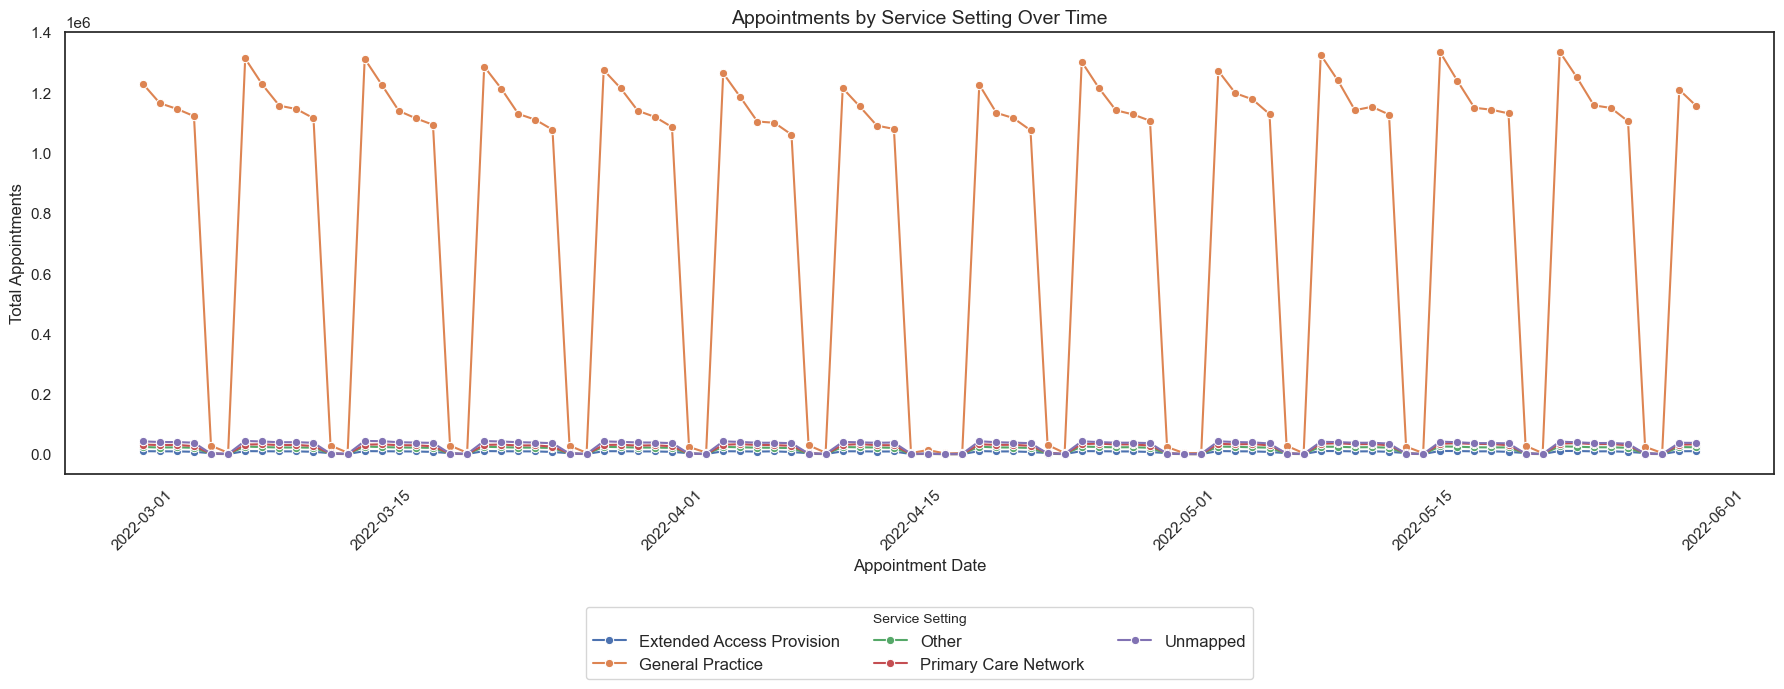

In [ ]:
# Create a lineplot
plt.figure(figsize=(18,6))

cx = sns.lineplot(
    data=service_per_season_4,
    x='Appointment Date',
    y='Total Appointments',
    hue='Service Setting',   # multiple lines
    marker='o'
)

plt.title('Appointments by Service Setting Over Time', fontsize=14)
plt.xlabel('Appointment Date', fontsize=12)
plt.ylabel('Total Appointments', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='Service Setting')
plt.tight_layout()

# Legend below the chart
cx.legend(
    title='Service Setting',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=3,
    fontsize=12,
    title_fontsize=10,
    frameon=True)

plt.show()

#

# Assignment Activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [ ]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [ ]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

print(f"Tweets: {tweets.shape}")
# View the DataFrame.
tweets.head()

Tweets: (1174, 10)


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [ ]:
# Explore the metadata.
print(tweets.info())
print(tweets.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std

In [ ]:
# Explore the data set.
print("Engagement Statistics:")
print(f"Total tweets: {len(tweets):,}")
print(f"Total retweets: {tweets['tweet_retweet_count'].sum():,}")
print(f"Total favorites: {tweets['tweet_favorite_count'].sum():,}")
print(f"Average retweets: {tweets['tweet_retweet_count'].mean():.2f}")
print(f"Average favorites: {tweets['tweet_favorite_count'].mean():.2f}")

Engagement Statistics:
Total tweets: 1,174
Total retweets: 10,131
Total favorites: 436
Average retweets: 8.63
Average favorites: 0.37


In [ ]:
tweets.duplicated().sum()

np.int64(0)

### Would it be useful to only look at retweeted and favourite tweet messages?

### Focusing only on retweeted and favourited tweets can highlight high-engagement content, which is useful for understanding what resonates with users. However, this approach may introduce bias by ignoring less popular tweets that could still contain important or diverse topics. Therefore, both high-engagement and overall data should be considered for balanced analysis.


In [ ]:
# Analysis
total = len(tweets)
with_retweets = (tweets['tweet_retweet_count'] > 0).sum()
with_favorites = (tweets['tweet_favorite_count'] > 0).sum()
with_engagement = ((tweets['tweet_retweet_count'] > 0) | 
                   (tweets['tweet_favorite_count'] > 0)).sum()

print(f"Tweets with retweets: {with_retweets:,} ({with_retweets/total*100:.1f}%)")
print(f"Tweets with favorites: {with_favorites:,} ({with_favorites/total*100:.1f}%)")
print(f"Tweets with any engagement: {with_engagement:,} ({with_engagement/total*100:.1f}%)")

print("\nYES - Focus on engaged tweets because:")
print("1. High engagement = content that resonated")
print("2. Retweets show sharing-worthy content")
print("3. Filters noise/spam")
print("4. Better indicator of trending topics")

Tweets with retweets: 648 (55.2%)
Tweets with favorites: 147 (12.5%)
Tweets with any engagement: 738 (62.9%)

YES - Focus on engaged tweets because:
1. High engagement = content that resonated
2. Retweets show sharing-worthy content
3. Filters noise/spam
4. Better indicator of trending topics


In [ ]:
# Create a new DataFrame containing only the text.
hashtag_text = tweets[['tweet_entities_hashtags']].copy()

# View the DataFrame.
hashtag_text.head()

,tweet_entities_hashtags
0,#Healthcare
1,"#PremiseHealth, #hiring"
2,#Healthcare
3,#NEW
4,"#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare"


In [ ]:
# Loop through the messages, and create a list of values containing the # symbol.
import re
from collections import Counter

# Extract all hashtags from the dataset
all_hashtags = []

# Loop through the hashtags column and extract hashtags
for hashtag_text in tweets['tweet_entities_hashtags'].dropna():
    # Extract hashtags using regex (looks for # followed by word characters)
    hashtags = re.findall(r'#\w+', str(hashtag_text))
    all_hashtags.extend(hashtags)

# Convert to lowercase for consistency
all_hashtags = [tag.lower() for tag in all_hashtags]

print(f"Total hashtags extracted: {len(all_hashtags):,}")
print(f"Unique hashtags: {len(set(all_hashtags)):,}")

print(f"\nSample hashtags:")
print(all_hashtags[:30])

Total hashtags extracted: 4,243
Unique hashtags: 1,497

Sample hashtags:
['#healthcare', '#premisehealth', '#hiring', '#healthcare', '#new', '#blogs', '#digitaltransformation', '#cybersecurity', '#accounting', '#finance', '#healthcare', '#firstcoastcna', '#cnaexam', '#cnaexampreparation', '#jacksonville', '#cnatraining', '#nurse', '#nursing', '#nurselife', '#nursepractitioner', '#nurseproblems', '#nursingschool', '#healthcare', '#new', '#disparities', '#healthcare', '#alert', '#insurance', '#data', '#healthcare']


In [ ]:
# Display the first 30 records.
hashtag_counts = Counter(all_hashtags)
top_30 = hashtag_counts.most_common(30)

print("Top 30 Hashtags:")
for i, (tag, count) in enumerate(top_30, 1):
    print(f"{i}. {tag}: {count}")

Top 30 Hashtags:
1. #healthcare: 844
2. #health: 86
3. #ai: 47
4. #medicine: 42
5. #job: 38
6. #medical: 35
7. #strategy: 31
8. #digitalhealth: 31
9. #pharmaceutical: 28
10. #medtwitter: 27
11. #competitiveintelligence: 25
12. #marketing: 25
13. #biotech: 25
14. #pharma: 25
15. #meded: 24
16. #telehealth: 22
17. #hiring: 21
18. #tipsfornewdocs: 21
19. #covid: 21
20. #vaccine: 18
21. #technology: 18
22. #healthtech: 18
23. #machinelearning: 18
24. #news: 17
25. #medicare: 17
26. #coronavirus: 16
27. #competitivemarketing: 16
28. #womeninmedicine: 16
29. #covid19: 15
30. #wellness: 15


In [ ]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtag_df = pd.DataFrame(hashtag_counts.most_common(), 
                          columns=['Hashtag', 'Count'])

# Display the result
hashtag_df 

,Hashtag,Count
0,#healthcare,844
1,#health,86
2,#ai,47
3,#medicine,42
4,#job,38
...,...,...
1492,#precisionfabrication,1
1493,#microfluidic,1
1494,#bpt,1
1495,#healthynation,1


In [ ]:
# Fix the count datatype.
hashtag_df['Count'] = hashtag_df['Count'].astype(int)



# View the result.
hashtag_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1497 entries, 0 to 1496
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Hashtag  1497 non-null   object
 1   Count    1497 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 23.5+ KB


In [ ]:
# Display records where the count is larger than 10.
# Display records where count > 10
popular_hashtags = hashtag_df[hashtag_df['Count'] > 10]
print(f"Hashtags with >10 mentions: {len(popular_hashtags)}")
print(popular_hashtags)

Hashtags with >10 mentions: 50
                        Hashtag  Count
0                   #healthcare    844
1                       #health     86
2                           #ai     47
3                     #medicine     42
4                          #job     38
5                      #medical     35
6                     #strategy     31
7                #digitalhealth     31
8               #pharmaceutical     28
9                   #medtwitter     27
10     #competitiveintelligence     25
11                   #marketing     25
12                     #biotech     25
13                      #pharma     25
14                       #meded     24
15                  #telehealth     22
16                      #hiring     21
17              #tipsfornewdocs     21
18                       #covid     21
19                     #vaccine     18
20                  #technology     18
21                  #healthtech     18
22             #machinelearning     18
23                        #news  

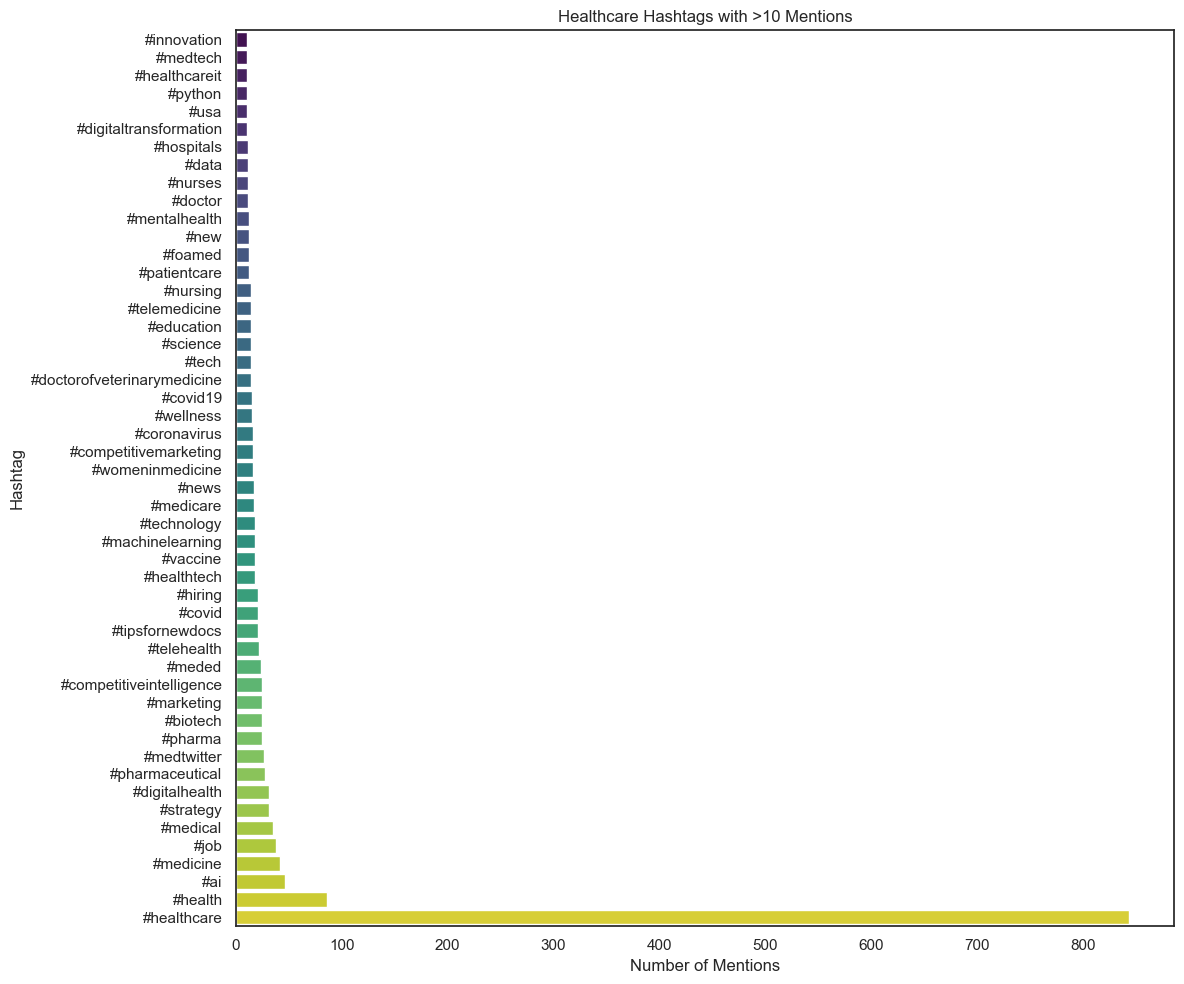


Top 5 Trending Topics:
  1. #healthcare - 844 mentions
  2. #health - 86 mentions
  3. #ai - 47 mentions
  4. #medicine - 42 mentions
  5. #job - 38 mentions


In [ ]:
# Create a Seaborn barplot indicating records with a count >10 records.
plot_data = hashtag_df[hashtag_df['Count'] > 10].sort_values('Count', ascending=True)

plt.figure(figsize=(12, 10))
sns.barplot(data=plot_data, y='Hashtag', x='Count', palette='viridis')
plt.xlabel('Number of Mentions')
plt.ylabel('Hashtag')
plt.title('Healthcare Hashtags with >10 Mentions')
plt.tight_layout()
plt.show()

# Key insights
print("\nTop 5 Trending Topics:")
for i, row in hashtag_df.head(5).iterrows():
    print(f"  {i+1}. {row['Hashtag']} - {row['Count']} mentions")

#

# Assignment Activity 6

### Make recommendations to the NHS.

In [ ]:
# Prepare your workstation.
# Load the appointments_regional.csv file.
# Load regional appointments
ar = pd.read_csv('appointments_regional.csv')
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Print min and max dates
print(f"Date range: {ar['appointment_month'].min()} to {ar['appointment_month'].max()}")

# View the DataFrame.
ar.head()

Date range: 2020-01-01 00:00:00 to 2022-06-01 00:00:00


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [ ]:
# Print the min and max dates.
ar_min = ar['appointment_month'].min()
ar_max = ar['appointment_month'].max()
print("Min Date:" ,ar_min)
print("Max Date:" ,ar_max)

Min Date: 2020-01-01 00:00:00
Max Date: 2022-06-01 00:00:00


In [ ]:
# Filter the data set to only look at data from 2021-08 onwards.
# Filter for August 2021 onwards
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01'].copy()

print(f"Original: {len(ar):,} rows")
print(f"Filtered: {len(ar_filtered):,} rows")
print(f"Date range: {ar_filtered['appointment_month'].min()} to {ar_filtered['appointment_month'].max()}")

Original: 596,821 rows
Filtered: 223,418 rows
Date range: 2021-08-01 00:00:00 to 2022-06-01 00:00:00


**Question 1:** Should the NHS start looking at increasing staff levels?

In [ ]:
# Create an aggregated data set to review the different features.
# Determine the total number of appointments per month.

ar_agg = ar_filtered.groupby('appointment_month').agg({
    'count_of_appointments': 'sum'
}).reset_index()

# View the DataFrame.
ar_agg

,appointment_month,count_of_appointments
0,2021-08-01,23852171
1,2021-09-01,28522501
2,2021-10-01,30303834
3,2021-11-01,30405070
4,2021-12-01,25140776
5,2022-01-01,25635474
6,2022-02-01,25355260
7,2022-03-01,29595038
8,2022-04-01,23913060
9,2022-05-01,27495508


In [ ]:
# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.

ar_agg['daily_average'] = (ar_agg['count_of_appointments'] / 30).round(2)
print("Monthly Statistics:")
print(f"Average monthly: {ar_agg['count_of_appointments'].mean():,.0f}")
print(f"Peak month: {ar_agg['count_of_appointments'].max():,.0f}")
print(f"Lowest month: {ar_agg['count_of_appointments'].min():,.0f}")
print(f"Std deviation: {ar_agg['count_of_appointments'].std():,.0f}")

# View the DataFrame.
ar_agg

Monthly Statistics:
Average monthly: 26,913,343
Peak month: 30,405,070
Lowest month: 23,852,171
Std deviation: 2,460,899


,appointment_month,count_of_appointments,daily_average
0,2021-08-01,23852171,795072.37
1,2021-09-01,28522501,950750.03
2,2021-10-01,30303834,1010127.80
3,2021-11-01,30405070,1013502.33
4,2021-12-01,25140776,838025.87
5,2022-01-01,25635474,854515.80
6,2022-02-01,25355260,845175.33
7,2022-03-01,29595038,986501.27
8,2022-04-01,23913060,797102.00
9,2022-05-01,27495508,916516.93


<Axes: xlabel='month_str', ylabel='count_of_appointments'>

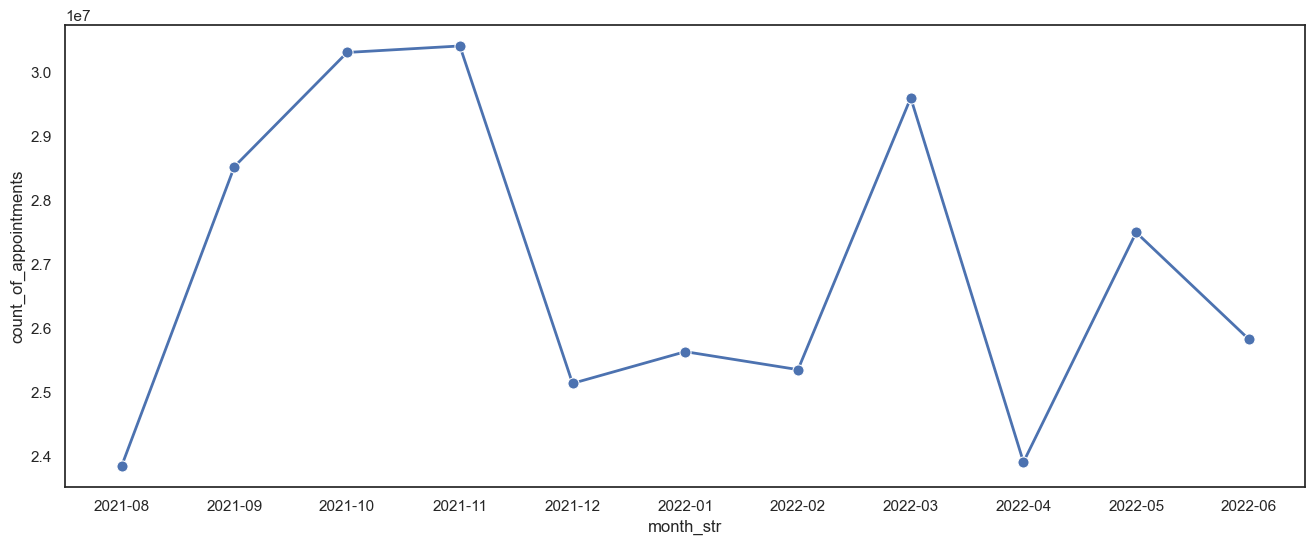

In [ ]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_agg['month_str'] = ar_agg['appointment_month'].dt.strftime('%Y-%m')

# Create a lineplot with Seaborn.
plt.figure(figsize=(16, 6))
sns.lineplot(data=ar_agg, x='month_str', y='count_of_appointments', 
             marker='o', linewidth=2, markersize=8)



capacity_threshold: 29374241.3


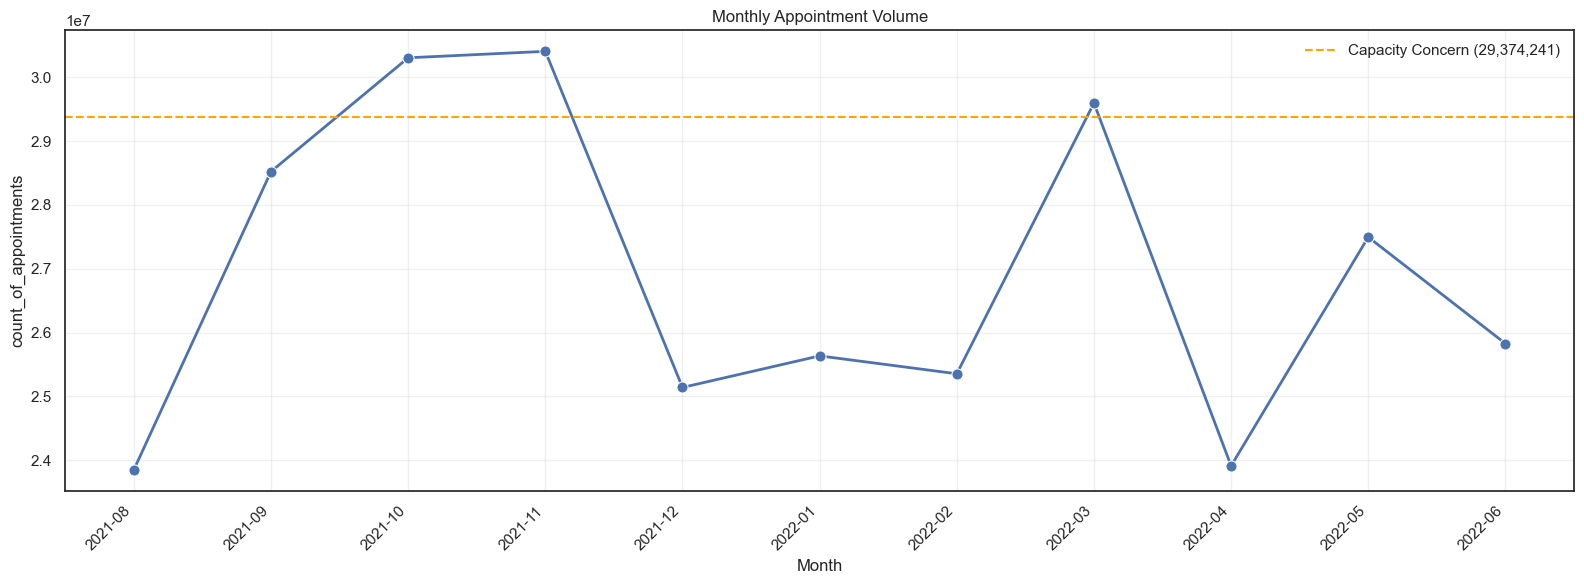

In [ ]:

# Calculate key statistics
avg_monthly = ar_agg['count_of_appointments'].mean()
std_monthly = ar_agg['count_of_appointments'].std()
peak_monthly = ar_agg['count_of_appointments'].max()
min_monthly = ar_agg['count_of_appointments'].min()
capacity_threshold = (avg_monthly + std_monthly).round(2)


print("capacity_threshold:" , capacity_threshold)
# Create a lineplot.
plt.figure(figsize=(16, 6))
sns.lineplot(data=ar_agg, x='month_str', y='count_of_appointments', 
             marker='o', linewidth=2, markersize=8)
# Plot monthly capacity utilisation.
plt.axhline(y=capacity_threshold, color='orange', linestyle='--', label=f'Capacity Concern ({capacity_threshold:,.0f})')

plt.xlabel('Month')
plt.ylabel('count_of_appointments')
plt.title('Monthly Appointment Volume')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question 2:** How do the healthcare professional types differ over time?

In [ ]:
# Create a line plot to answer the question.

# Group by month and HCP type
hcp_monthly = ar_filtered.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().unstack(fill_value=0)
hcp_monthly

hcp_type,GP,Other Practice staff,Unknown
appointment_month,,,
2021-08-01,12299022,10797821,755328
2021-09-01,14487785,13126731,907985
2021-10-01,14300751,14942504,1060579
2021-11-01,14897749,14432800,1074521
2021-12-01,12654767,11614470,871539
2022-01-01,13138050,11705142,792282
2022-02-01,12869711,11688107,797442
2022-03-01,15127227,13528583,939228
2022-04-01,11908463,11217738,786859


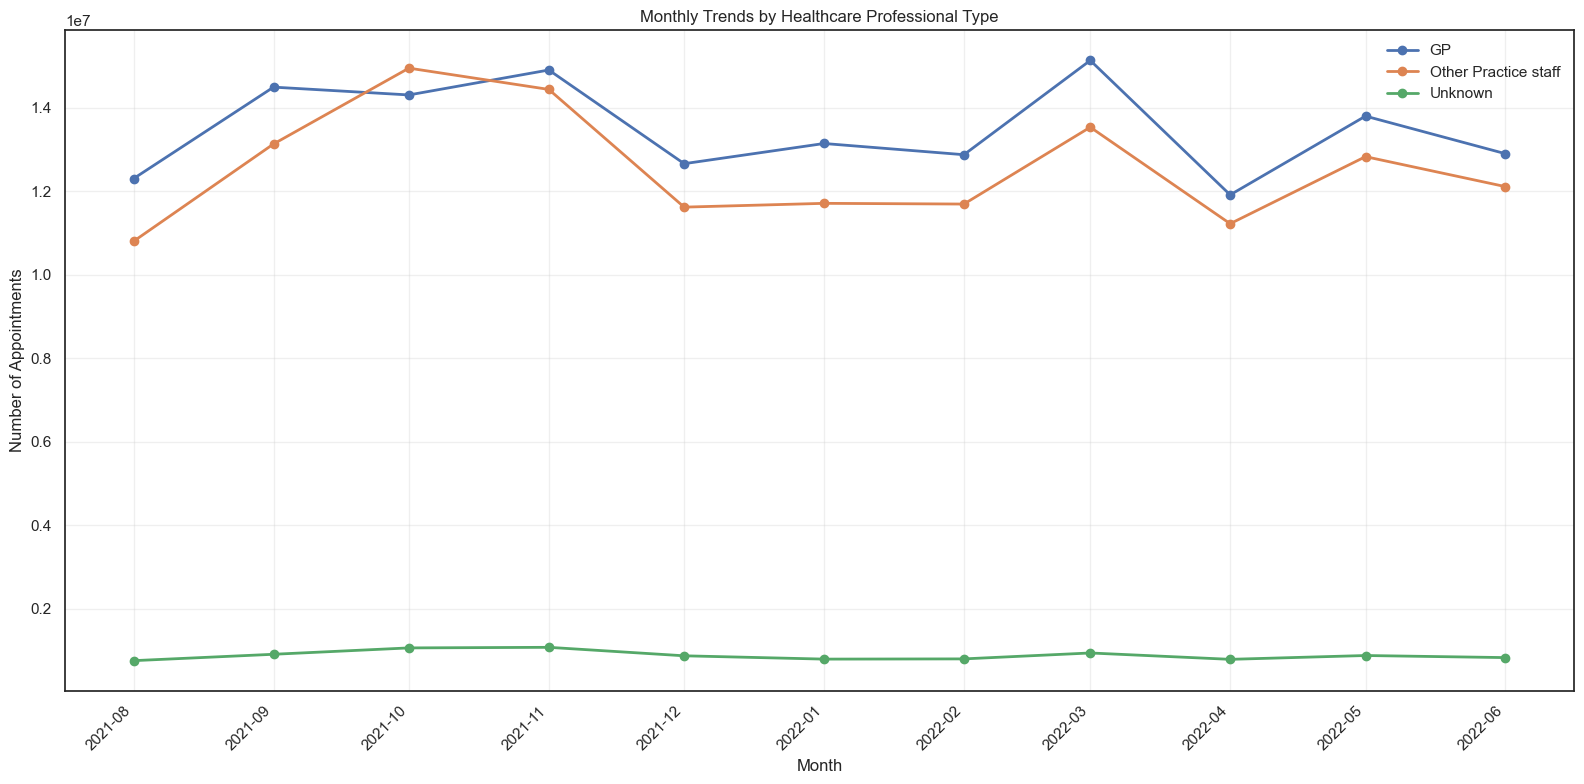

In [ ]:
# Plot
plt.figure(figsize=(16, 8))
for hcp in hcp_monthly.columns:
    plt.plot(hcp_monthly.index, hcp_monthly[hcp], 
             marker='o', linewidth=2, label=hcp)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Trends by Healthcare Professional Type')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question 3:** Are there significant changes in whether or not visits are attended?

appointment_status  Attended      DNA  Unknown
appointment_month                             
2021-08-01          22081765   949137   821269
2021-09-01          25757066  1321348  1444087
2021-10-01          27170506  1565624  1567704
2021-11-01          27667665  1428087  1309318
2021-12-01          22853483  1198866  1088427
2022-01-01          23597196  1076013   962265
2022-02-01          23351939  1076658   926663
2022-03-01          27170002  1289888  1135148
2022-04-01          21948814  1045455   918791
2022-05-01          25343941  1199518   952049
2022-06-01          23715317  1167790   944971


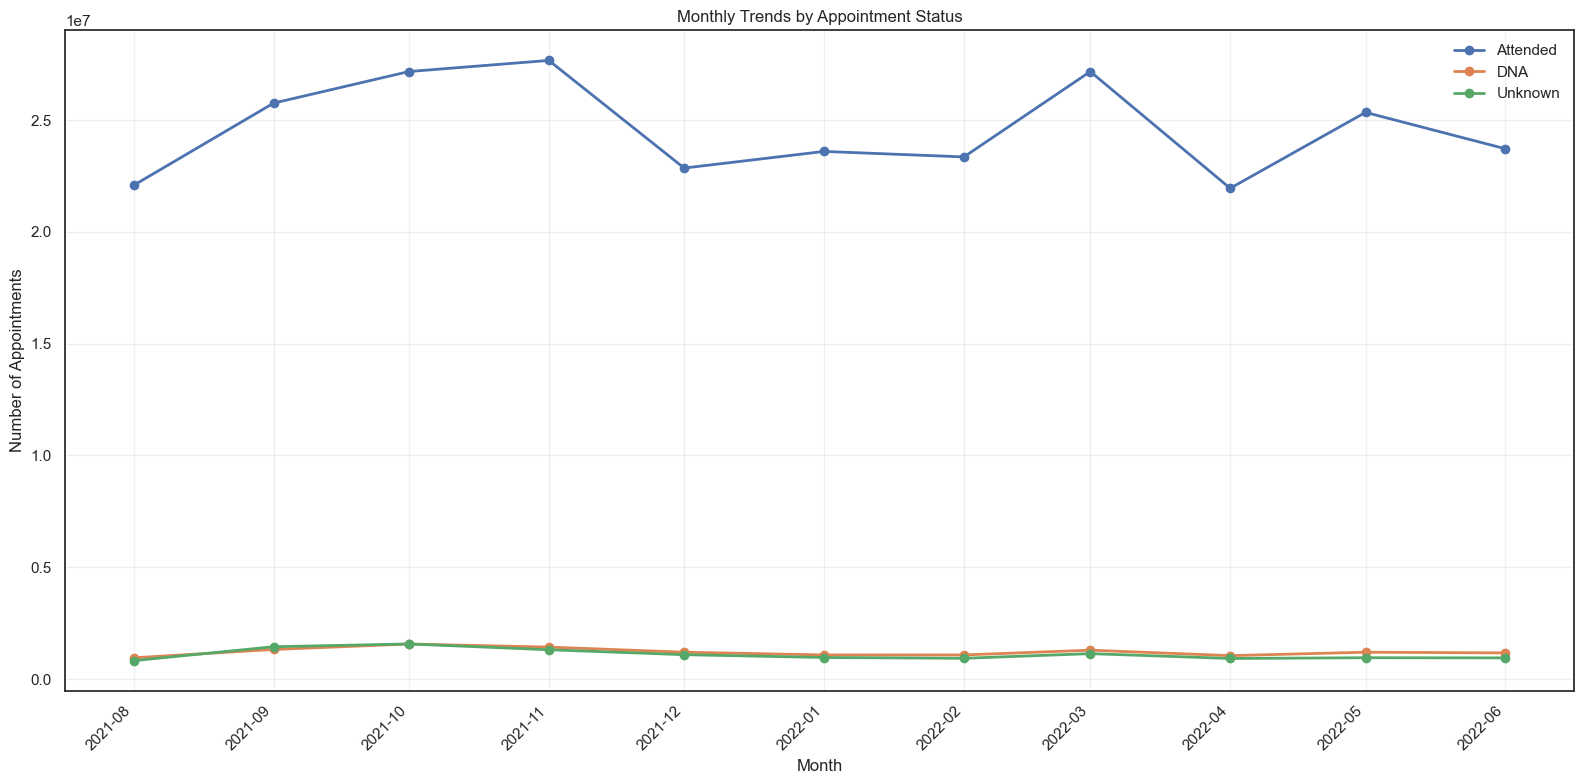

In [ ]:
# Create a line plot to answer the question.
# Group by month and status
status_monthly = ar_filtered.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().unstack(fill_value=0)
print(status_monthly)
# Plot
plt.figure(figsize=(16, 8))
for status in status_monthly.columns:
    plt.plot(status_monthly.index, status_monthly[status], 
             marker='o', linewidth=2, label=status)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Trends by Appointment Status')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

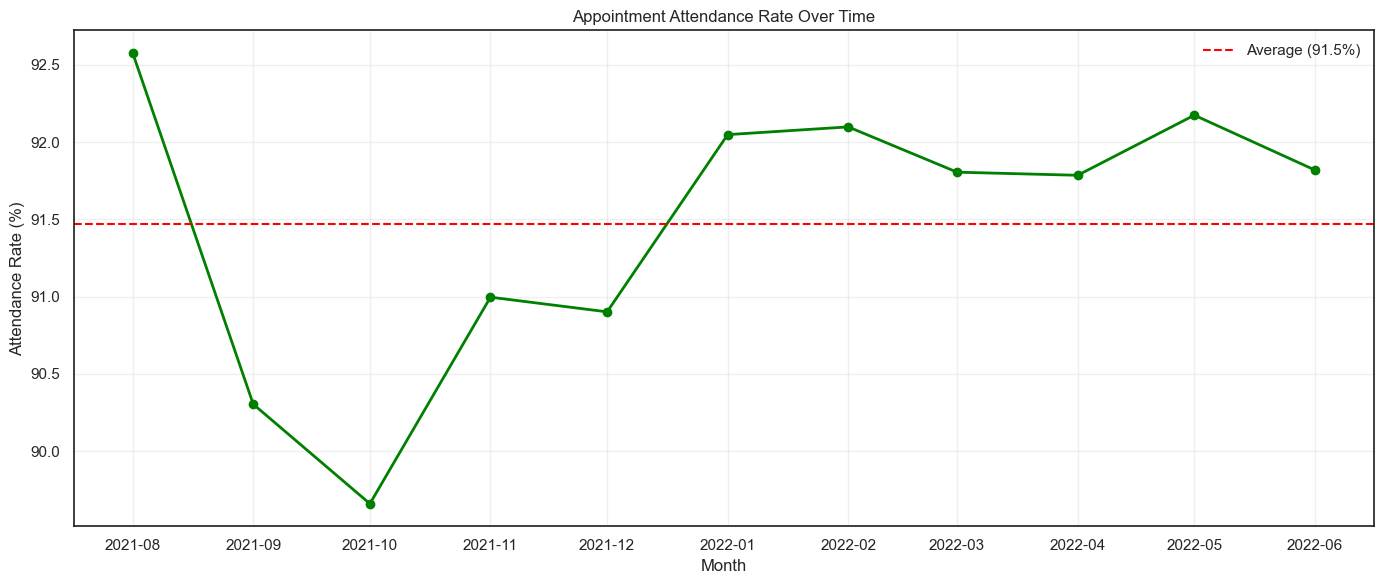

Average attendance: 91.47%


In [ ]:
# Calculate rates
if 'Attended' in status_monthly.columns:
    total = status_monthly.sum(axis=1)
    attendance_rate = (status_monthly['Attended'] / total * 100)
    
    plt.figure(figsize=(14, 6))
    plt.plot(attendance_rate.index, attendance_rate.values, 
             marker='o', linewidth=2, color='green')
    plt.axhline(y=attendance_rate.mean(), color='red', linestyle='--', 
                label=f'Average ({attendance_rate.mean():.1f}%)')
    plt.xlabel('Month')
    plt.ylabel('Attendance Rate (%)')
    plt.title('Appointment Attendance Rate Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Average attendance: {attendance_rate.mean():.2f}%")

**Question 4:** Are there changes in terms of appointment type and the busiest months?

appointment_mode   Face-to-Face  Home Visit  Telephone  Unknown  Video/Online
appointment_month                                                            
2021-08-01             13717325      151619    9149072   724126        110029
2021-09-01             17266602      171829   10068770   859946        155354
2021-10-01             19471561      178593    9449544  1029671        174465
2021-11-01             19031327      203352    9993842  1015969        160580
2021-12-01             15312340      181264    8723325   798049        125798
2022-01-01             15414102      171669    9212553   706352        130798
2022-02-01             15531971      170435    8820538   704619        127697
2022-03-01             18333743      200945   10088419   819913        152018
2022-04-01             15049567      172936    7893805   670299        126453
2022-05-01             17630858      200862    8792743   726857        144188
2022-06-01             16744191      187640    8082270   677860 

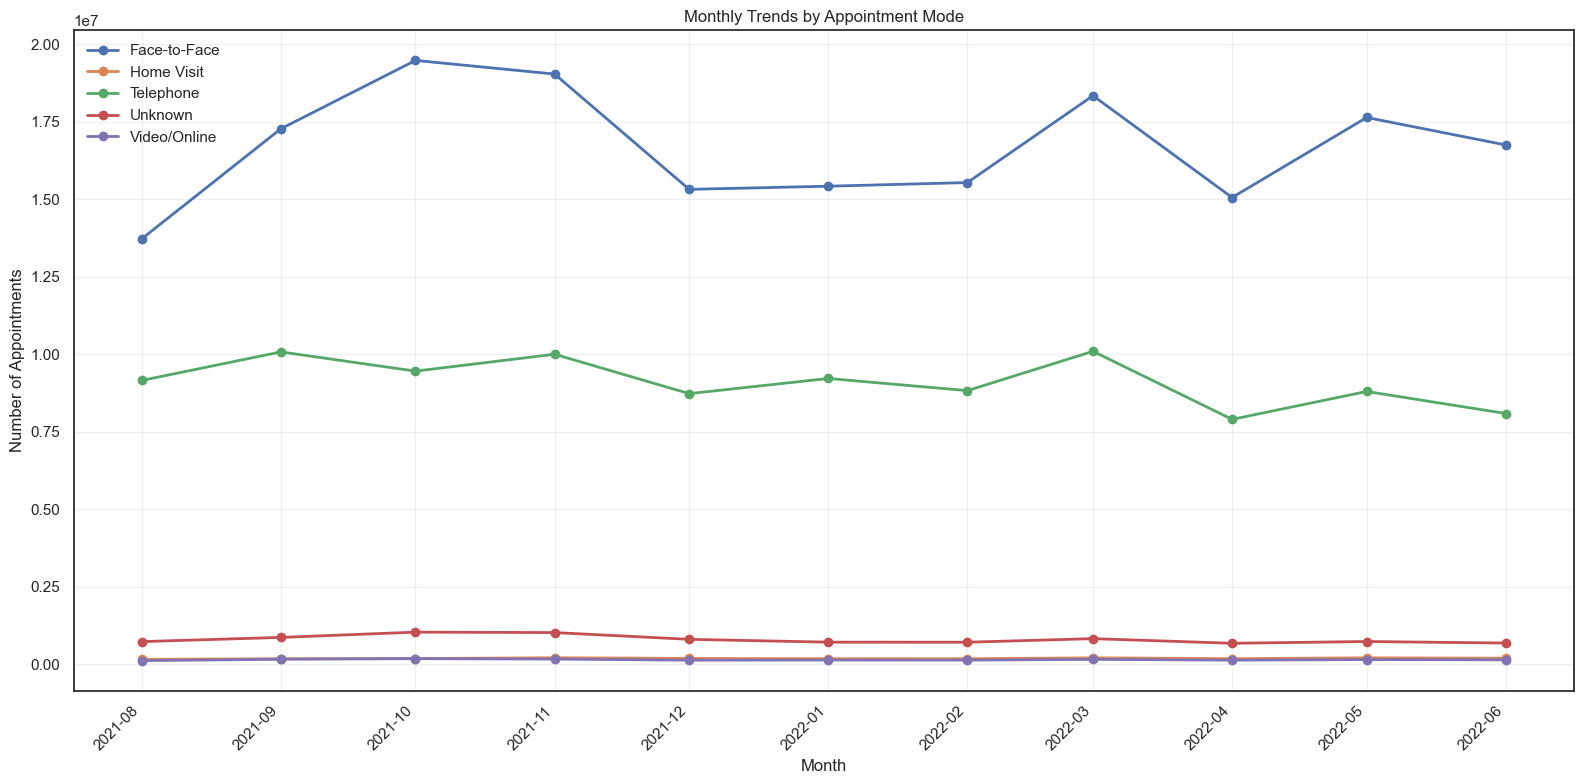

In [ ]:
# Create a line plot to answer the question.
# Group by month and mode
mode_monthly = ar_filtered.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().unstack(fill_value=0)
print(mode_monthly)
# Plot
plt.figure(figsize=(16, 8))
for mode in mode_monthly.columns:
    plt.plot(mode_monthly.index, mode_monthly[mode], 
             marker='o', linewidth=2, label=mode)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Trends by Appointment Mode')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Busiest months per mode
print("Busiest Month by Mode:")
for mode in mode_monthly.columns:
    busiest = mode_monthly[mode].idxmax()
    max_val = mode_monthly[mode].max()
    print(f"{mode}: {busiest.strftime('%B %Y')} ({max_val:,})")

Busiest Month by Mode:
Face-to-Face: October 2021 (19,471,561)
Home Visit: November 2021 (203,352)
Telephone: March 2022 (10,088,419)
Unknown: October 2021 (1,029,671)
Video/Online: October 2021 (174,465)


**Question 5:** Are there any trends in time between booking and appointment?

time_between_book_and_appointment    1 Day  15  to 21 Days  2 to 7 Days  \
appointment_month                                                         
2021-08-01                         2018319         1453209      4924960   
2021-09-01                         2666072         1869263      5955074   
2021-10-01                         2598516         2005851      6811322   
2021-11-01                         2506532         2254189      6335266   
2021-12-01                         2219212         1709999      4740529   
2022-01-01                         2334274         1312377      5621812   
2022-02-01                         2272923         1524398      5466290   
2022-03-01                         2709362         1908058      6079566   
2022-04-01                         2088881         1720218      4527185   
2022-05-01                         2270686         1782026      5565378   
2022-06-01                         2188197         1914740      4706718   

time_between_book_and_ap

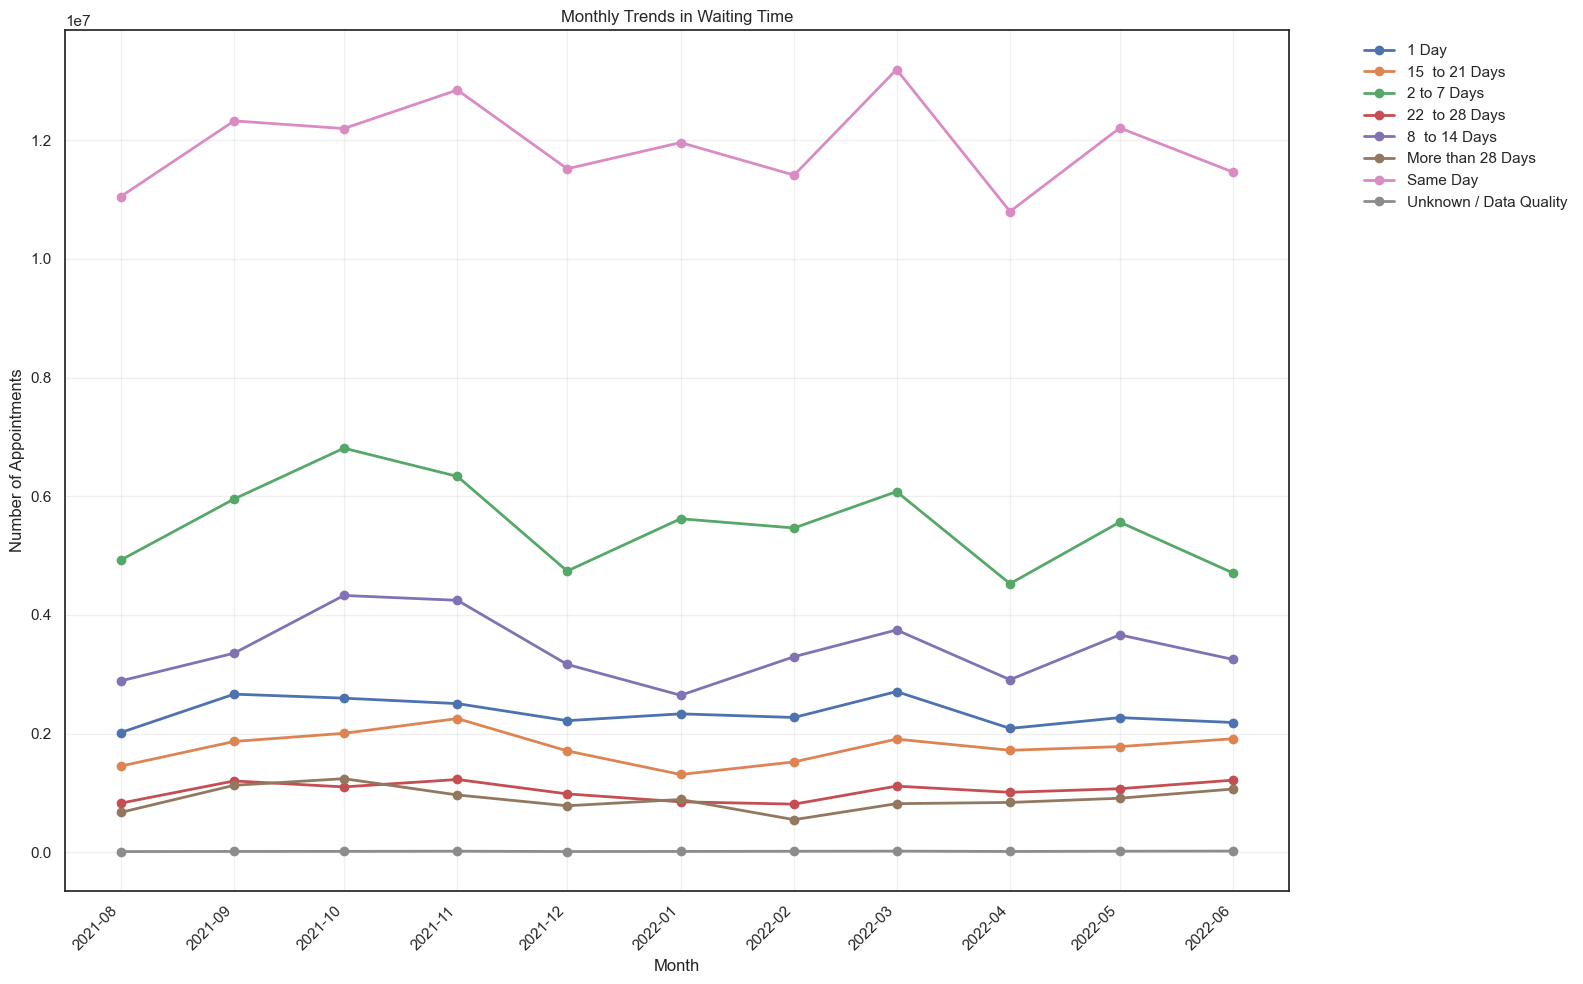

In [ ]:
# Create a line plot to answer the question.

# Group by month and waiting time
waiting_monthly = ar_filtered.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'].sum().unstack(fill_value=0)
print(waiting_monthly)
# Plot
plt.figure(figsize=(16, 10))
for wait in waiting_monthly.columns:
    plt.plot(waiting_monthly.index, waiting_monthly[wait], 
             marker='o', linewidth=2, label=wait)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Trends in Waiting Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Capacity analysis
long_wait_cats = ['15 to 21 Days', '22 to 28 Days', 'More than 28 Days']
available = [cat for cat in long_wait_cats if cat in waiting_monthly.columns]

if available:
    long_wait_total = waiting_monthly[available].sum(axis=1)
    total = waiting_monthly.sum(axis=1)
    long_wait_pct = (long_wait_total / total * 100)
    
    print(f"\nAverage % with >14 days wait: {long_wait_pct.mean():.2f}%")
    print(f"Trend: {'Increasing' if long_wait_pct.iloc[-1] > long_wait_pct.iloc[0] else 'Decreasing'}")


Average % with >14 days wait: 3.32%
Trend: Increasing


###  In the post-Aug 2021 period, same-day and 1-day appointments dominate, but long waits (>14 days) show a gradual upward creep toward mid-2022 — a warning sign that capacity pressure is beginning to push patients further out in the queue. If this trend is increasing, it is the single strongest argument for the staffing recommendation in Q1.

**Question 6:** How do the various service settings compare?

In [ ]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.


In [ ]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
# Create aggregated data
nc_monthly = nc.groupby(['month', 'service_setting'])['count_of_appointments'].sum().reset_index()
# View the DataFrame.
nc_monthly

,month,service_setting,count_of_appointments
0,1,Extended Access Provision,186375
1,1,General Practice,23583053
2,1,Other,457440
3,1,Primary Care Network,569044
4,1,Unmapped,839562
5,2,Extended Access Provision,196627
6,2,General Practice,23305934
7,2,Other,456153
8,2,Primary Care Network,585300
9,2,Unmapped,811246


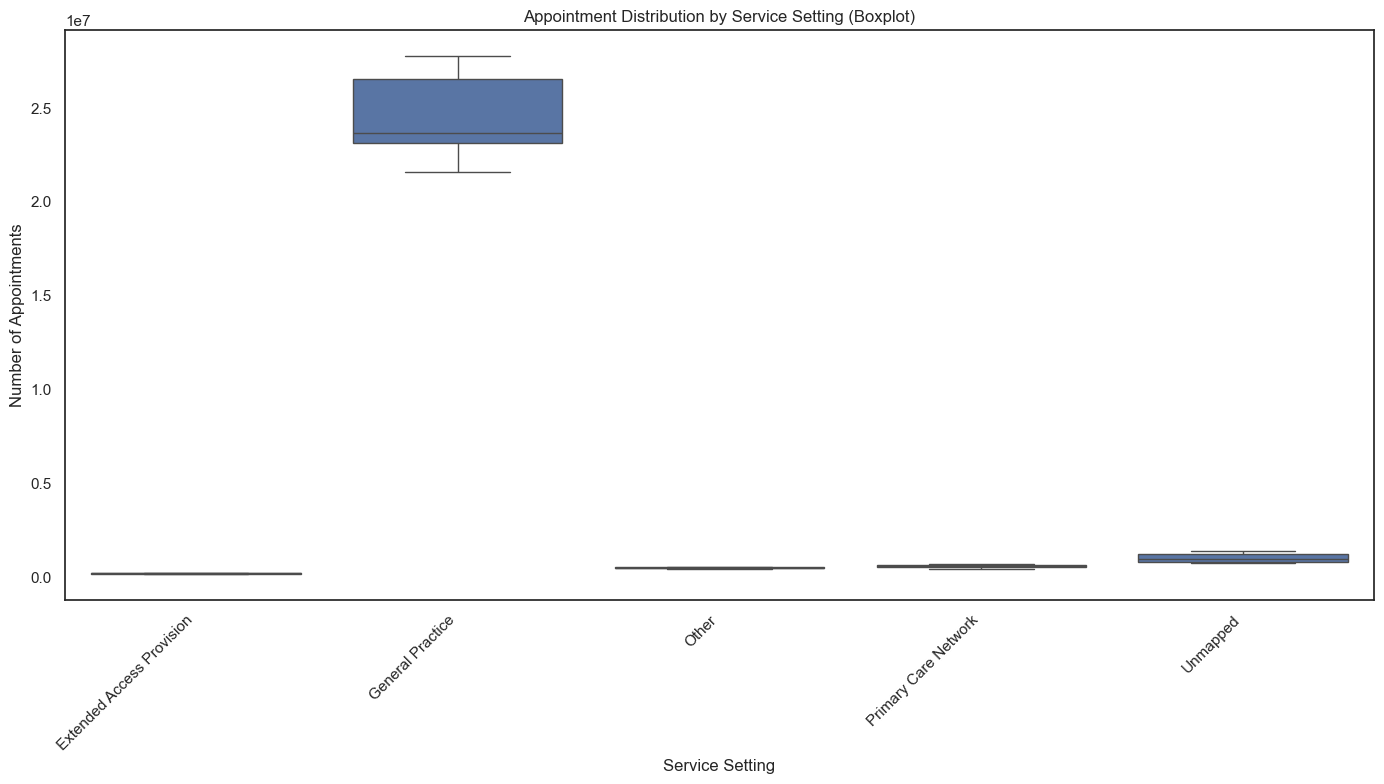

In [ ]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
# Boxplot by service setting
plt.figure(figsize=(14, 8))
sns.boxplot(data=nc_monthly, x='service_setting', y='count_of_appointments')
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.title('Appointment Distribution by Service Setting (Boxplot)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

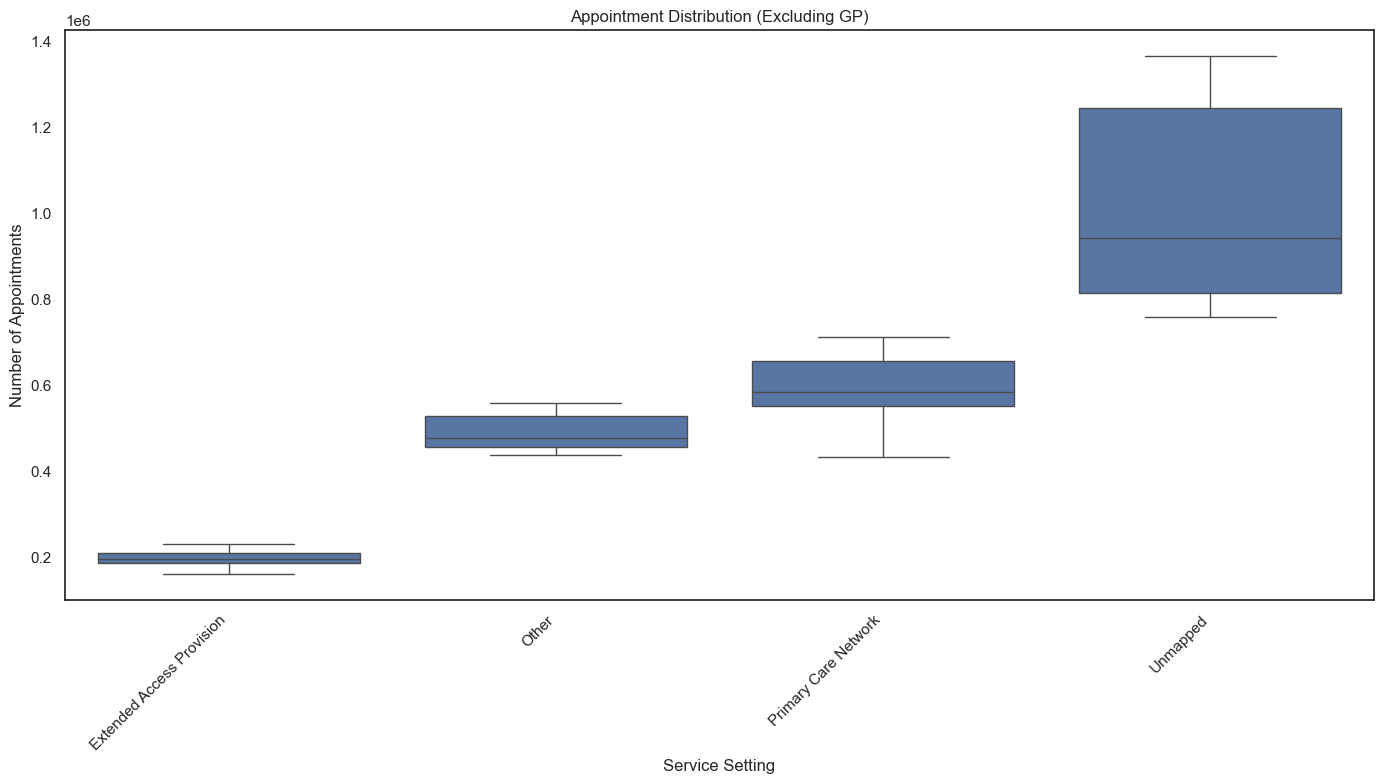

In [ ]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
# Boxplot excluding GP
nc_no_gp = nc_monthly[~nc_monthly['service_setting'].str.contains('GP|General Practice', case=False, na=False)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=nc_no_gp, x='service_setting', y='count_of_appointments')
plt.xlabel('Service Setting')
plt.ylabel('Number of Appointments')
plt.title('Appointment Distribution (Excluding GP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### The boxplot analysis (with and without GP) is particularly revealing. With GP included, it completely dominates the scale — making other settings invisible. The excluding-GP boxplot is therefore the more useful chart for the NHS, showing the spread of appointments across Extended Access, Other, and Unknown settings. The wide interquartile ranges in non-GP settings indicate high month-to-month variability, suggesting these services are reactive rather than planned — another signal that capacity planning at the non-GP level needs improvement.

#

### Provide a summary of your findings and recommendations based on the analysis.

> Double click to insert your summary.
### Key Findings
1. Dataset Overview
The analysis draws on three NHS datasets covering different time windows: appointment duration data (December 2021 – June 2022), regional appointment data (January 2020 – June 2022), and national category data (August 2021 – June 2022). NHS England is organised across 7 regions, 42 Integrated Care Boards (ICBs), and 106 sub-ICB locations.
2. Service Settings & Appointment Types
General Practice dominates NHS activity, accounting for 91.5% of all appointments across 5 service settings. Of the 3 context types, Care Related Encounters represent 86.8% of appointments. Across 18 national categories, routine general consultations are the most common (32.9%), followed by acute general consultations (18.1%).
3. Appointment Modes
Face-to-face appointments account for 59.2% of appointments and telephone for 36.1%. However, the picture has shifted significantly since 2020: telephone consultations, which stood at just 14.6% in January 2020, surged to 50.6% by April 2020 during the first COVID-19 lockdown. Although face-to-face appointments have been recovering since, their share remains below pre-pandemic levels.
4. Attendance & DNA Rates
Of all appointments, 91.3% were attended, 4.2% were DNA (Did Not Attend), and 4.6% had unknown status. While attendance is high overall, the DNA rate represents a meaningful source of wasted capacity that could be addressed.
5. Waiting Times
The majority of appointments (46.2%) take place on the same day they are booked, with a further 20.7% within 2–7 days. This suggests strong same-day demand rather than a systemic long-wait problem — though monitoring of 15+ day waits remains important.
6. Healthcare Professional (HCP) Types
GPs handled 51.1% of appointments, with other practice staff covering 45.7%. The balance between these two groups has been relatively stable but should be monitored as demand grows.
7. Appointment Duration
24% of appointments have no recorded duration, which is a data quality concern. Of those with known durations, most are short: 20% last 6–10 minutes and 17% last 1–5 minutes — consistent with the high volume of brief GP consultations.
8. COVID-19 Impact & Seasonal Trends
There were clear dips in total appointments during the first lockdown (March–April 2020), the second period of restrictions (October 2020 – February 2021), and again in December 2021 – February 2022 (Omicron wave). Across seasons, General Practice consistently dominates in every period (summer, autumn, winter, and spring 2021–2022), with other service settings remaining comparatively flat.
9. Social Media Insights (Twitter): The hashtag analysis supports the operational findings: workforce recruitment (#job, #hiring) and digital transformation (#digitalhealth, #telehealth, #ai) are the dominant public themes, reinforcing the recommendations around staffing increases and hybrid appointment models.